# TFG — Estabilidad y coherencia de las explicaciones SHAP en *credit scoring*

**Grado en Ciencia e Ingeniería de Datos — Universidade da Coruña**

Notebook de un experimento sobre el dataset:
**Default of Credit Card Clients (Taiwán, UCI #350)**.

---

## Qué hace este notebook

Se entrenan dos modelos sobre las **mismas particiones y la misma matriz de diseño**:

- una **regresión logística** (interpretable por construcción, que actúa como línea base),
- un **XGBoost** (caja negra), explicado con **TreeSHAP**.

Sobre ellos se ejecutan los cuatro análisis de la propuesta de trabajo:

| # | Análisis | Pregunta |
|---|----------|----------|
| 1 | **Concordancia** | ¿Dice SHAP-XGBoost lo mismo que la logística? |
| 2 | **Estabilidad ante el entrenamiento** | ¿Cambian las explicaciones al reentrenar (semilla + bootstrap)? |
| 3 | **Estabilidad ante el conjunto de referencia** | ¿Cambia la explicación de un cliente al cambiar el *background*? |
| 4 | **Consistencia y coherencia** | ¿Clientes casi idénticos reciben explicaciones parecidas? ¿Los efectos tienen sentido financiero? |

El análisis 2 y 3 están pensados para repetirse después sobre **South German Credit**
(segundo dataset); la estructura del notebook está modularizada para que solo haya que
cambiar el bloque de carga y el diccionario de variables.

---

## Índice

0. [Configuración y reproducibilidad](#s0)
1. [Carga del dataset](#s1)
2. [Análisis exploratorio (EDA)](#s2)
3. [Limpieza y matriz de diseño](#s3)
4. [Entrenamiento de los dos modelos](#s4)
5. [Evaluación predictiva comparada](#s5)
6. [Explicaciones SHAP (caso base)](#s6)
7. [Análisis 1 — Concordancia logística vs. SHAP-XGBoost](#s7)
8. [Análisis 2 — Estabilidad ante el reentrenamiento](#s8)
9. [Análisis 3 — Estabilidad ante el conjunto de referencia](#s9)
10. [Análisis 4 — Consistencia y coherencia](#s10)
11. [Resumen de resultados y exportación](#s11)

<a id="s0"></a>
## 0. Configuración y reproducibilidad

Todas las decisiones que afectan al experimento están concentradas aquí para poder
documentarlas en la memoria y variarlas sin tocar el resto del notebook.

> **Requisitos:** las dependencias están fijadas en `pyproject.toml` (raíz del repositorio); se instalan con `uv sync` y el notebook se ejecuta con el kernel `TFG SHAP` del entorno virtual `.venv`. Equivalente con pip: `pip install numpy pandas scikit-learn scipy matplotlib seaborn xgboost shap xlrd`.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import re
import sys
import time
import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import shap
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("pandas", pd.__version__, "| sklearn OK | xgboost", xgb.__version__, "| shap", shap.__version__)

pandas 2.3.3 | sklearn OK | xgboost 2.1.4 | shap 0.49.1


In [2]:
# ----------------------------------------------------------------------------------
# PARÁMETROS DEL EXPERIMENTO
# ----------------------------------------------------------------------------------
SEED = 42                 # semilla maestra
TEST_SIZE = 0.25          # proporción del conjunto de test (estratificado)

N_REPEATS = 100           # repeticiones del análisis de estabilidad (Lin y Wang usan 100)
BOOTSTRAP_FRAC = 1.0      # tamaño de la remuestra bootstrap respecto al train (1.0 = bootstrap clásico)

N_EXPLAIN = 200           # nº de clientes de test cuyas explicaciones locales se siguen
BACKGROUND_SIZE = 200     # tamaño del conjunto de referencia (background) para TreeSHAP interventional
TOP_K = 5                 # tamaño del "top" en las medidas de solapamiento de rankings

# Hiperparámetros fijos: el objeto de estudio es la estabilidad, no el tuning. Son valores
# convencionales para tabular de este tamaño (profundidad moderada y muchos árboles con tasa
# de aprendizaje baja); la profundidad se somete a comprobación de robustez en el apartado 11.2.
XGB_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    # La matriz es numérica pura: con enable_categorical=False, TreeSHAP interventional
    # no tiene que tratar ninguna variable como categórica.
    enable_categorical=False,
    n_jobs=-1,
)
LR_PARAMS = dict(penalty="l2", C=1.0, max_iter=2000, solver="lbfgs")

# Rutas (relativas a la carpeta code/, desde la que se ejecuta el notebook)
DATA_DIR = Path("..") / "data" / "default+of+credit+card+clients"
OUT_DIR = Path("resultados")
FIG_DIR = OUT_DIR / "figuras"
TAB_DIR = OUT_DIR / "tablas"
for d in (OUT_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
PALETA = {"lr": "#4C72B0", "xgb": "#C44E52"}


def guardar_fig(nombre: str):
    """Guarda la figura actual en resultados/figuras para poder insertarla en la memoria."""
    plt.savefig(FIG_DIR / f"{nombre}.png")
    plt.show()


def guardar_tabla(df: pd.DataFrame, nombre: str, **kw):
    """Guarda una tabla de resultados en CSV."""
    df.to_csv(TAB_DIR / f"{nombre}.csv", **kw)
    return df


@contextlib.contextmanager
def sin_barra_de_progreso():
    """Oculta la barra de progreso de SHAP sin perder el resto de stderr.

    Cuando el calculo de TreeSHAP interventional pasa de diez segundos, la extension en C de
    shap dibuja una barra de progreso que ensucia la salida del notebook, y TreeExplainer no
    tiene ningun argumento para desactivarla. La escribe con PySys_WriteStderr, es decir, sobre
    el objeto `sys.stderr` que haya puesto en ese momento, asi que basta con sustituirlo por un
    buffer mientras dura el calculo. Al salir se vuelve a emitir lo capturado descartando solo
    las lineas de barra, para no silenciar avisos reales.
    """
    buffer = io.StringIO()
    original, sys.stderr = sys.stderr, buffer
    try:
        yield
    finally:
        sys.stderr = original
        resto = [ln for ln in buffer.getvalue().replace("\r", "\n").splitlines()
                 if ln.strip() and not re.match(r"^\s*\d+%\|", ln)]
        if resto:
            print("\n".join(resto), file=sys.stderr)


print(f"Semilla maestra: {SEED} | Repeticiones de estabilidad: {N_REPEATS}")

Semilla maestra: 42 | Repeticiones de estabilidad: 100


<a id="s1"></a>
## 1. Carga del dataset

**Default of Credit Card Clients** (Yeh y Lien, 2009). 30.000 clientes de tarjeta de
crédito de un banco de Taiwán, abril–septiembre de 2005. 23 variables predictoras y la
variable objetivo `default payment next month` (≈22 % de positivos).

Se lee del fichero local indicado en `RUTA_DATOS`. Sirven tanto el `.xls` original de UCI
(que tiene una fila de cabecera adicional, por eso `header=1`, y necesita `pip install
xlrd`) como la copia `UCI_Credit_Card.csv` de Kaggle: los nombres de columna se
normalizan a un esquema único.

Dos renombrados que conviene documentar en la memoria: la variable objetivo pasa a
llamarse `DEFAULT`, y `PAY_0` pasa a `PAY_1`, porque el fichero original salta de `PAY_0`
a `PAY_2` y esa numeración es una fuente habitual de confusión al interpretar resultados.

In [3]:
# Ruta al fichero descargado. Si se deja en None, se busca el único fichero de datos
# que haya en la carpeta data/.
RUTA_DATOS: Optional[Path] = None

RENOMBRES = {
    "default payment next month": "DEFAULT",
    "default.payment.next.month": "DEFAULT",
    "Y": "DEFAULT",
    "PAY_0": "PAY_1",
}

COLUMNAS_ESPERADAS = (
    ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
    + [f"PAY_{i}" for i in range(1, 7)]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
    + ["DEFAULT"]
)


def localizar_fichero(data_dir: Path = DATA_DIR) -> Path:
    candidatos = [p for p in sorted(data_dir.glob("*")) if p.suffix.lower() in (".xls", ".xlsx", ".csv")]
    if not candidatos:
        raise FileNotFoundError(
            f"No hay ningún .xls/.csv en '{data_dir.resolve()}'. Deja en esa carpeta el fichero de UCI "
            "(default of credit card clients.xls) o el de Kaggle (UCI_Credit_Card.csv), "
            "o indica la ruta en RUTA_DATOS."
        )
    if len(candidatos) > 1:
        print(f"Aviso: hay {len(candidatos)} ficheros en data/; se usa {candidatos[0].name}. "
              "Indica RUTA_DATOS si quieres otro.")
    return candidatos[0]


def cargar_taiwan(ruta: Optional[Path] = RUTA_DATOS) -> pd.DataFrame:
    ruta = Path(ruta) if ruta is not None else localizar_fichero()
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el fichero '{ruta.resolve()}'.")

    if ruta.suffix.lower() in (".xls", ".xlsx"):
        # El .xls de UCI trae una fila de cabecera extra por encima de los nombres reales
        d = pd.read_excel(ruta, header=1)
    else:
        d = pd.read_csv(ruta)

    d = d.rename(columns=lambda c: str(c).strip()).rename(columns=RENOMBRES)
    d = d.drop(columns=[c for c in ("ID",) if c in d.columns])
    print(f"Cargado: {ruta}")
    return d


def verificar(d: pd.DataFrame) -> None:
    """Comprobaciones de integridad: si algo falla, mejor saberlo aquí que 40 celdas después."""
    faltan = [c for c in COLUMNAS_ESPERADAS if c not in d.columns]
    assert not faltan, f"Faltan columnas: {faltan}"
    sobran = [c for c in d.columns if c not in COLUMNAS_ESPERADAS]
    if sobran:
        print(f"Aviso: columnas no esperadas que se ignorarán en el análisis: {sobran}")
    no_num = [c for c in COLUMNAS_ESPERADAS if not pd.api.types.is_numeric_dtype(d[c])]
    assert not no_num, f"Columnas no numéricas (¿fila de cabecera mal leída?): {no_num}"
    assert set(d["DEFAULT"].unique()) <= {0, 1}, "La variable objetivo no es binaria 0/1"
    if len(d) != 30000:
        print(f"Aviso: se esperaban 30.000 filas y hay {len(d):,}.")
    print(f"Verificación superada: {d.shape[0]:,} filas x {d.shape[1]} columnas, "
          f"{d.isna().sum().sum()} valores perdidos, tasa de impago {d['DEFAULT'].mean():.4f}")


df_raw = cargar_taiwan()
verificar(df_raw)
df_raw.head()

Cargado: ..\data\default+of+credit+card+clients\default of credit card clients.xls
Verificación superada: 30,000 filas x 24 columnas, 0 valores perdidos, tasa de impago 0.2212


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.1 Diccionario de variables

Se define de forma explícita porque se reutiliza en todo el notebook (etiquetas de los
gráficos, signo financiero esperado en el análisis 4, tablas de la memoria).

In [4]:
DICCIONARIO = {
    "LIMIT_BAL": "Límite de crédito concedido (NT$)",
    "SEX": "Sexo (1=hombre, 2=mujer)",
    "EDUCATION": "Nivel educativo (1=posgrado, 2=universidad, 3=secundaria, 4=otros)",
    "MARRIAGE": "Estado civil (1=casado, 2=soltero, 3=otros)",
    "AGE": "Edad (años)",
    **{f"PAY_{i}": f"Estado de pago hace {i} mes(es) (-1=al corriente, 0=revolving, 1..9=meses de retraso)" for i in range(1, 7)},
    **{f"BILL_AMT{i}": f"Importe facturado hace {i} mes(es) (NT$)" for i in range(1, 7)},
    **{f"PAY_AMT{i}": f"Importe pagado hace {i} mes(es) (NT$)" for i in range(1, 7)},
    "DEFAULT": "Impago en el mes siguiente (1=sí)",
}

# Signo esperado del efecto sobre la probabilidad de impago (para el análisis de coherencia).
SIGNO_ESPERADO = {
    "LIMIT_BAL": -1,   # más límite concedido -> cliente mejor evaluado -> menos riesgo
    "AGE": 0,          # sin expectativa clara
    **{f"PAY_{i}": +1 for i in range(1, 7)},      # más retraso -> más riesgo
    **{f"PAY_AMT{i}": -1 for i in range(1, 7)},   # paga más -> menos riesgo
    **{f"BILL_AMT{i}": 0 for i in range(1, 7)},   # ambiguo: mide uso, no impago
}

pd.DataFrame({"variable": list(DICCIONARIO), "descripción": list(DICCIONARIO.values())})

,variable,descripción
0,LIMIT_BAL,Límite de crédito concedido (NT$)
1,SEX,"Sexo (1=hombre, 2=mujer)"
2,EDUCATION,"Nivel educativo (1=posgrado, 2=universidad, 3=..."
3,MARRIAGE,"Estado civil (1=casado, 2=soltero, 3=otros)"
4,AGE,Edad (años)
5,PAY_1,Estado de pago hace 1 mes(es) (-1=al corriente...
6,PAY_2,Estado de pago hace 2 mes(es) (-1=al corriente...
7,PAY_3,Estado de pago hace 3 mes(es) (-1=al corriente...
8,PAY_4,Estado de pago hace 4 mes(es) (-1=al corriente...
9,PAY_5,Estado de pago hace 5 mes(es) (-1=al corriente...


<a id="s2"></a>
## 2. Análisis exploratorio (EDA)

El objetivo del EDA aquí no es solo describir: es **detectar lo que puede contaminar el
análisis de estabilidad**. En concreto interesan (a) el desequilibrio de clases, porque
Chen et al. (2024) lo señalan como factor que degrada la estabilidad de las
explicaciones; (b) las categorías no documentadas, que si se dejan crudas generan
variables one-hot con muy pocos casos y por tanto explicaciones muy inestables; y (c) la
correlación entre las `BILL_AMT`, que reparte la atribución entre variables redundantes.

In [5]:
print("Filas y columnas:", df_raw.shape)
print("\nValores perdidos por columna:", df_raw.isna().sum().sum(), "en total")
print("Filas duplicadas:", df_raw.duplicated().sum())
df_raw.dtypes.to_frame("tipo").T

Filas y columnas: (30000, 24)

Valores perdidos por columna: 0 en total
Filas duplicadas: 35


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
tipo,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


Tasa de impago: 0.2212  (6,636 de 30,000)
Ratio de desequilibrio: 1 : 3.52


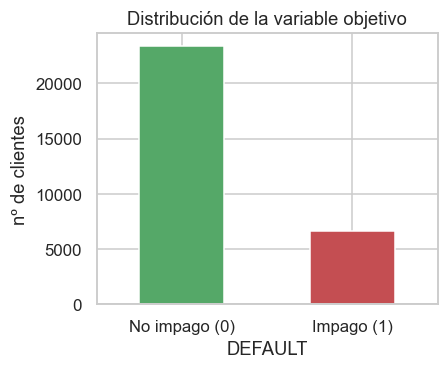

In [6]:
tasa = df_raw["DEFAULT"].mean()
print(f"Tasa de impago: {tasa:.4f}  ({df_raw['DEFAULT'].sum():,} de {len(df_raw):,})")
print(f"Ratio de desequilibrio: 1 : {(1 - tasa) / tasa:.2f}")

fig, ax = plt.subplots(figsize=(4, 3.2))
df_raw["DEFAULT"].value_counts().sort_index().plot.bar(ax=ax, color=["#55A868", "#C44E52"])
ax.set_xticklabels(["No impago (0)", "Impago (1)"], rotation=0)
ax.set_ylabel("nº de clientes")
ax.set_title("Distribución de la variable objetivo")
guardar_fig("01_target")

In [7]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0


### 2.1 Categorías no documentadas

`EDUCATION` está documentada con 4 niveles (1–4) y `MARRIAGE` con 3 (1–3), pero en los
datos aparecen códigos adicionales (`0`, `5`, `6`) que la documentación de UCI no
describe. Es un problema conocido de este dataset y hay que resolverlo antes de modelar.

In [8]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    vc = df_raw[col].value_counts().sort_index()
    print(f"\n{col}")
    print(pd.DataFrame({"n": vc, "%": (100 * vc / len(df_raw)).round(2)}).T.to_string())


SEX
SEX         1         2
n    11888.00  18112.00
%       39.63     60.37

EDUCATION
EDUCATION      0         1         2        3       4       5      6
n          14.00  10585.00  14030.00  4917.00  123.00  280.00  51.00
%           0.05     35.28     46.77    16.39    0.41    0.93   0.17

MARRIAGE
MARRIAGE      0         1         2       3
n         54.00  13659.00  15964.00  323.00
%          0.18     45.53     53.21    1.08


In [9]:
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

print("Distribución conjunta de los códigos de PAY_1..PAY_6:")
conteo_pay = pd.concat([df_raw[c].value_counts() for c in pay_cols], axis=1).fillna(0).astype(int).sort_index()
conteo_pay.columns = pay_cols
conteo_pay

Distribución conjunta de los códigos de PAY_1..PAY_6:


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


Los códigos `-2` (sin consumo en el mes) y `0` (uso de crédito *revolving*, pago mínimo)
no están en la documentación original, que solo describe `-1` (pagado al corriente) y
`1..9` (meses de retraso). Se tratan como una escala ordinal
(`-2 < -1 < 0 < 1 < ...`), que es lo que hacen Lin y Wang (2025) y la mayoría de la
literatura sobre este dataset; la alternativa (one-hot) se anota como comprobación de
robustez para la memoria.

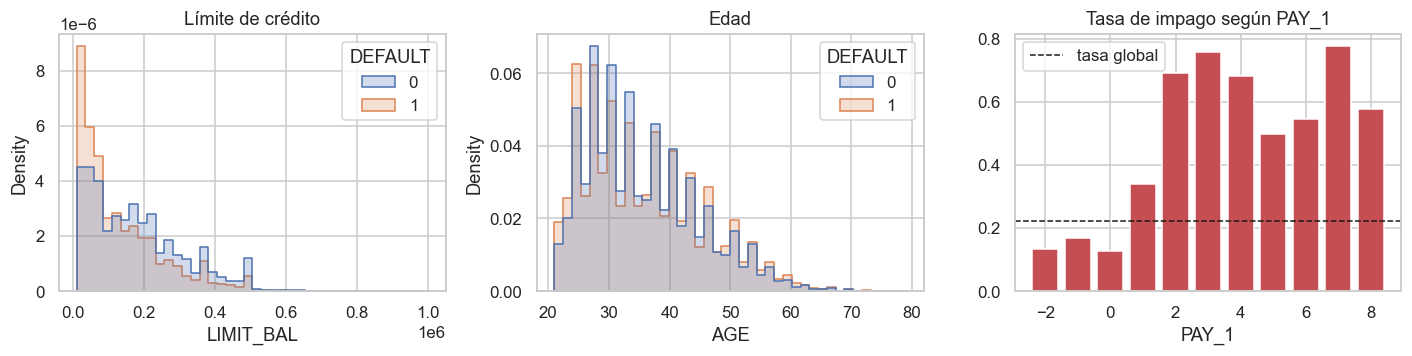

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
sns.histplot(df_raw, x="LIMIT_BAL", hue="DEFAULT", bins=40, ax=axes[0], element="step", stat="density", common_norm=False)
axes[0].set_title("Límite de crédito")
sns.histplot(df_raw, x="AGE", hue="DEFAULT", bins=40, ax=axes[1], element="step", stat="density", common_norm=False)
axes[1].set_title("Edad")
tasa_pay = df_raw.groupby("PAY_1")["DEFAULT"].agg(["mean", "size"])
axes[2].bar(tasa_pay.index, tasa_pay["mean"], color="#C44E52")
axes[2].axhline(tasa, ls="--", c="k", lw=1, label="tasa global")
axes[2].set_title("Tasa de impago según PAY_1")
axes[2].set_xlabel("PAY_1")
axes[2].legend()
plt.tight_layout()
guardar_fig("02_distribuciones")

`PAY_1` (el estado de pago del mes más reciente) separa las clases de forma muy marcada:
es de esperar que domine ambos modelos. Eso es relevante para el análisis 2, porque Lin y
Wang (2025) encuentran justamente que las variables dominantes son estables y las
intermedias no.

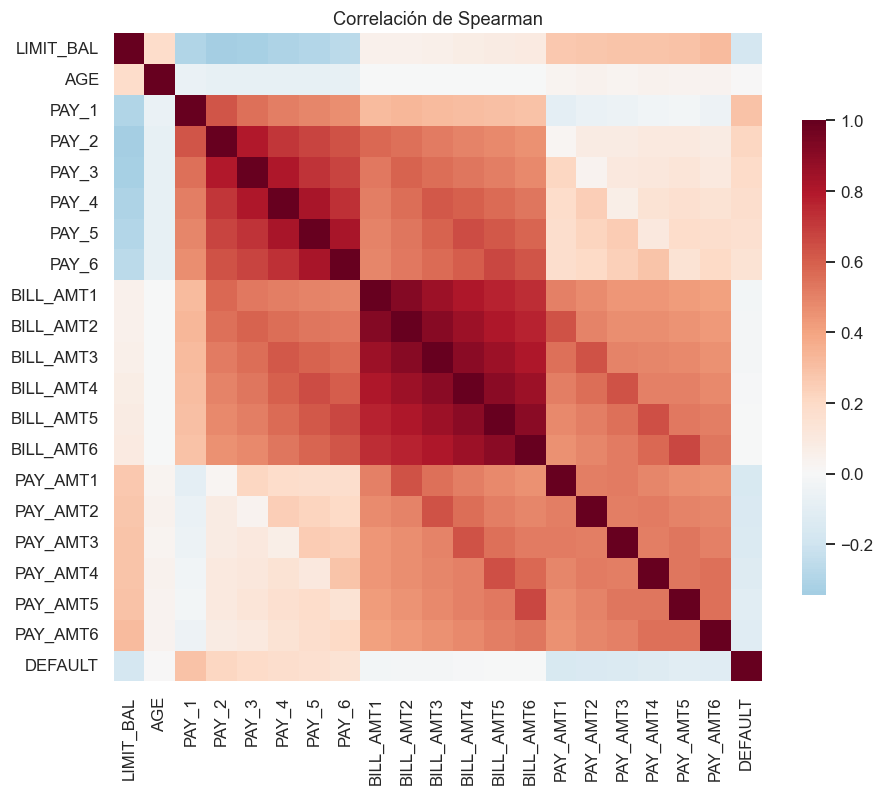

Correlación media entre las BILL_AMT: 0.841


In [11]:
num_cols = ["LIMIT_BAL", "AGE"] + pay_cols + bill_cols + amt_cols
corr = df_raw[num_cols + ["DEFAULT"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación de Spearman")
guardar_fig("03_correlacion")

print("Correlación media entre las BILL_AMT:",
      round(corr.loc[bill_cols, bill_cols].values[np.triu_indices(6, 1)].mean(), 3))

Las seis `BILL_AMT` están fuertemente correlacionadas entre sí (son el saldo del mismo
cliente en meses consecutivos). Esto importa para la interpretación de SHAP: ante
variables redundantes la atribución se reparte entre ellas y puede cambiar de reparto
entre reentrenamientos aunque el modelo prediga lo mismo. Es una de las hipótesis a
contrastar en el análisis 2.

<a id="s3"></a>
## 3. Limpieza y matriz de diseño

Decisión de diseño importante: **los dos modelos comparten exactamente la misma matriz de
features**. Sin eso, la comparación del análisis 1 no sería válida (se estarían comparando
atribuciones sobre espacios distintos). Como XGBoost es invariante a transformaciones
monótonas de las variables, estandarizar no le afecta; y la regresión logística sí
necesita el escalado y el *one-hot*.

En el *one-hot* se toma como **categoría de referencia la más frecuente** de cada variable
(mujer, universidad, soltero) en lugar de la primera alfabética. Si la referencia fuese una
categoría rara (por ejemplo `EDUCATION = otros`, con menos del 2 % de los clientes), las
dummies restantes serían casi colineales entre sí, sus coeficientes en la logística se
inflarían y compensarían unos a otros, y aparecerían con una importancia SHAP artificialmente
alta que distorsionaría la comparación del análisis 1.

In [12]:
def limpiar(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # EDUCATION: 0, 5 y 6 no están documentados -> se agrupan en la categoría 4 ("otros")
    d["EDUCATION"] = d["EDUCATION"].replace({0: 4, 5: 4, 6: 4}).clip(1, 4)
    # MARRIAGE: 0 no está documentado -> categoría 3 ("otros")
    d["MARRIAGE"] = d["MARRIAGE"].replace({0: 3}).clip(1, 3)
    return d


df = limpiar(df_raw)

print("Después de la limpieza:")
for c in ["EDUCATION", "MARRIAGE"]:
    print(f"  {c}: {sorted(df[c].unique())}")

Después de la limpieza:
  EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


In [13]:
CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
NUM_COLS = ["LIMIT_BAL", "AGE"] + pay_cols + bill_cols + amt_cols

ETIQUETAS_CAT = {
    "SEX": {1: "hombre", 2: "mujer"},
    "EDUCATION": {1: "posgrado", 2: "universidad", 3: "secundaria", 4: "otros"},
    "MARRIAGE": {1: "casado", 2: "soltero", 3: "otros"},
}


def construir_matriz(d: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    y = d["DEFAULT"].astype(int)
    cat = d[CAT_COLS].replace(ETIQUETAS_CAT).astype(str)
    # Categoría de referencia = la más frecuente de cada variable (se elimina su dummy)
    referencia = {c: cat[c].mode()[0] for c in CAT_COLS}
    X_cat = pd.get_dummies(cat, prefix=CAT_COLS, dtype=float)
    X_cat = X_cat.drop(columns=[f"{c}_{ref}" for c, ref in referencia.items()])
    X = pd.concat([d[NUM_COLS].astype(float), X_cat], axis=1)
    print("Categorías de referencia (dummy eliminada):", referencia)
    return X, y


X_all, y_all = construir_matriz(df)
FEATURES = list(X_all.columns)
print(f"{len(FEATURES)} variables en la matriz de diseño:")
print(FEATURES)

Categorías de referencia (dummy eliminada): {'SEX': 'mujer', 'EDUCATION': 'universidad', 'MARRIAGE': 'soltero'}
26 variables en la matriz de diseño:
['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_hombre', 'EDUCATION_otros', 'EDUCATION_posgrado', 'EDUCATION_secundaria', 'MARRIAGE_casado', 'MARRIAGE_otros']


In [14]:
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED
)

scaler = StandardScaler().fit(X_tr_raw[NUM_COLS])


def escalar(X: pd.DataFrame) -> pd.DataFrame:
    Xs = X.copy()
    Xs[NUM_COLS] = scaler.transform(X[NUM_COLS])
    return Xs


X_tr, X_te = escalar(X_tr_raw), escalar(X_te_raw)

print(f"Train: {X_tr.shape}  (tasa impago {y_tr.mean():.4f})")
print(f"Test:  {X_te.shape}  (tasa impago {y_te.mean():.4f})")

# Duplicados exactos. El dataset tiene filas repetidas si se descarta el identificador. No se
# eliminan: son clientes distintos con el mismo perfil observado, y quitarlos cambiaria la
# muestra que describe el informe. Lo que si conviene saber es cuantos grupos de perfiles
# identicos quedan repartidos entre train y test, porque eso es una fuga de informacion.
perfiles = X_all.assign(_clase=y_all)
huella = pd.util.hash_pandas_object(perfiles, index=False)
repetidas = huella[huella.duplicated(keep=False)]
reparto = pd.DataFrame({"huella": repetidas,
                        "en_train": perfiles.index[huella.duplicated(keep=False)].isin(X_tr.index)})
cruzan = int(reparto.groupby("huella")["en_train"].nunique().eq(2).sum())
print(f"\nFilas con perfil y clase repetidos: {int(huella.duplicated().sum())} "
      f"| grupos de perfiles identicos partidos entre train y test: {cruzan}")

Train: (22500, 26)  (tasa impago 0.2212)
Test:  (7500, 26)  (tasa impago 0.2212)



Filas con perfil y clase repetidos: 35 | grupos de perfiles identicos partidos entre train y test: 13


### 3.1 Conjuntos fijos de explicación y de referencia

Se fijan **una sola vez** y se reutilizan en todos los análisis:

- **Conjunto de explicación**: los clientes de test cuyas explicaciones locales se siguen
  a lo largo de las repeticiones. Se estratifica por la clase real para que haya
  suficientes impagos.
- **Conjunto de referencia (*background*)**: la muestra de train respecto a la cual se
  calculan los SHAP *interventional*. García-Céspedes et al. (2025) muestran que esta
  elección cambia las explicaciones, así que se documenta explícitamente y es el objeto
  del análisis 3.

Una decisión que conviene dejar por escrito, porque afecta al análisis 2: el `StandardScaler`
se ajusta **una sola vez** sobre el conjunto de entrenamiento completo y no se reajusta en
cada remuestra bootstrap. Las atribuciones de LinearSHAP son `beta_j (x_j − E[x_j])`, o sea
que dependen de la escala; si el escalado cambiase en cada repetición, la variabilidad medida
mezclaría dos fuentes: el reentrenamiento del modelo y el reescalado de las variables. Fijarlo
deja solo la primera, que es la que se quiere medir. La contrapartida es que la remuestra ve
una media y una desviación típica calculadas sobre datos que incluyen sus propias filas; como
el escalado no usa la variable respuesta, no introduce fuga hacia el test.

In [15]:
n_por_clase = min(N_EXPLAIN // 2, y_te.value_counts().min())
idx_expl = X_te.groupby(y_te.values).sample(n=n_por_clase, random_state=SEED).index
X_expl = X_te.loc[idx_expl]
y_expl = y_te.loc[idx_expl]

X_bg = X_tr.sample(n=BACKGROUND_SIZE, random_state=SEED)

print(f"Conjunto de explicación: {X_expl.shape} (impagos: {int(y_expl.sum())})")
print(f"Conjunto de referencia:  {X_bg.shape} (tasa impago {y_tr.loc[X_bg.index].mean():.3f})")

Conjunto de explicación: (200, 26) (impagos: 100)
Conjunto de referencia:  (200, 26) (tasa impago 0.200)


<a id="s4"></a>
## 4. Entrenamiento de los dos modelos

In [16]:
def entrenar_lr(X, y, seed=SEED):
    return LogisticRegression(random_state=seed, **LR_PARAMS).fit(X, y)


def entrenar_xgb(X, y, seed=SEED):
    m = xgb.XGBClassifier(random_state=seed, **XGB_PARAMS)
    m.fit(X, y)
    return m


t0 = time.time()
modelo_lr = entrenar_lr(X_tr, y_tr)
modelo_xgb = entrenar_xgb(X_tr, y_tr)
print(f"Entrenados en {time.time() - t0:.1f} s")

# El escalado solo estandariza NUM_COLS: las dummies siguen siendo 0/1, así que un coeficiente
# crudo mezcla "log-odds por desviación típica" con "log-odds por salto de 0 a 1" y sobrevalora
# a las categorías raras. Se acompaña de |beta|·SD(x), que sí es comparable entre columnas.
beta = pd.Series(modelo_lr.coef_[0], index=FEATURES)
sd_x = X_tr.std()
coefs = pd.DataFrame({
    "beta (log-odds)": beta,
    "SD(x)": sd_x,
    "|beta|·SD(x)": (beta.abs() * sd_x),
    "frecuencia" : X_tr.mean().where(X_tr.isin([0, 1]).all(), np.nan),
}).sort_values("|beta|·SD(x)", ascending=False)
guardar_tabla(coefs.round(4), "coeficientes_logistica")
coefs.head(12).round(3)

Entrenados en 1.2 s


,beta (log-odds),SD(x),|beta|·SD(x),frecuencia
PAY_1,0.650,1.000,0.650,NaN
BILL_AMT1,-0.330,1.000,0.330,NaN
PAY_AMT2,-0.214,1.000,0.214,NaN
PAY_AMT1,-0.187,1.000,0.187,NaN
EDUCATION_otros,-1.012,0.128,0.129,0.017
LIMIT_BAL,-0.117,1.000,0.117,NaN
BILL_AMT3,0.104,1.000,0.104,NaN
PAY_2,0.099,1.000,0.099,NaN
PAY_3,0.096,1.000,0.096,NaN
MARRIAGE_casado,0.179,0.498,0.089,0.454


El orden por `|beta|` crudo y por `|beta|·SD(x)` no coincide, y la diferencia no es cosmética:
una dummy que solo vale 1 en una minoría de clientes puede tener un coeficiente grande y aun así
mover muy poco la predicción del conjunto. Por eso el análisis 1 usa **SHAP sobre la logística**
como referencia y no los coeficientes crudos: `phi_j(x) = beta_j (x_j - E[x_j])` ya incorpora la
dispersión de la variable. La tabla siguiente lo hace explícito para las variables donde más
cambia el orden.

In [17]:
orden_crudo = beta.abs().rank(ascending=False)
orden_escalado = (beta.abs() * sd_x).rank(ascending=False)
orden_shap = importancia_global(sv_lr).rank(ascending=False) if "sv_lr" in dir() else None

comparativa_escala = pd.DataFrame({
    "rank |beta|": orden_crudo,
    "rank |beta|·SD(x)": orden_escalado,
    "salto": (orden_crudo - orden_escalado).abs(),
}).sort_values("salto", ascending=False)
print("Variables cuyo puesto más cambia según se use el coeficiente crudo o escalado:")
comparativa_escala.head(8).round(1)

Variables cuyo puesto más cambia según se use el coeficiente crudo o escalado:


,rank |beta|,rank |beta|·SD(x),salto
MARRIAGE_otros,13.0,25.0,12.0
EDUCATION_posgrado,9.0,16.0,7.0
SEX_hombre,8.0,13.0,5.0
EDUCATION_otros,1.0,5.0,4.0
MARRIAGE_casado,6.0,10.0,4.0
BILL_AMT3,10.0,7.0,3.0
BILL_AMT2,15.0,12.0,3.0
PAY_3,12.0,9.0,3.0


<a id="s5"></a>
## 5. Evaluación predictiva comparada

Antes de comparar explicaciones hay que comprobar que los dos modelos son **comparables en
rendimiento**: si el XGBoost no superase a la logística, la premisa del trabajo
(Lessmann et al., 2015) no se sostendría en estos datos.

In [18]:
def metricas(y_true, p) -> dict:
    fpr, tpr, _ = roc_curve(y_true, p)
    return {
        "ROC-AUC": roc_auc_score(y_true, p),
        "PR-AUC": average_precision_score(y_true, p),
        "KS": float(np.max(tpr - fpr)),
        "Brier": brier_score_loss(y_true, p),
        "LogLoss": log_loss(y_true, p),
    }


p_lr = modelo_lr.predict_proba(X_te)[:, 1]
p_xgb = modelo_xgb.predict_proba(X_te)[:, 1]

tabla_rend = pd.DataFrame(
    {"Regresión logística": metricas(y_te, p_lr), "XGBoost": metricas(y_te, p_xgb)}
).T.round(4)
guardar_tabla(tabla_rend, "rendimiento_modelos")
tabla_rend

,ROC-AUC,PR-AUC,KS,Brier,LogLoss
Regresión logística,0.7175,0.5033,0.3695,0.1455,0.4668
XGBoost,0.7789,0.5563,0.4310,0.1349,0.4300


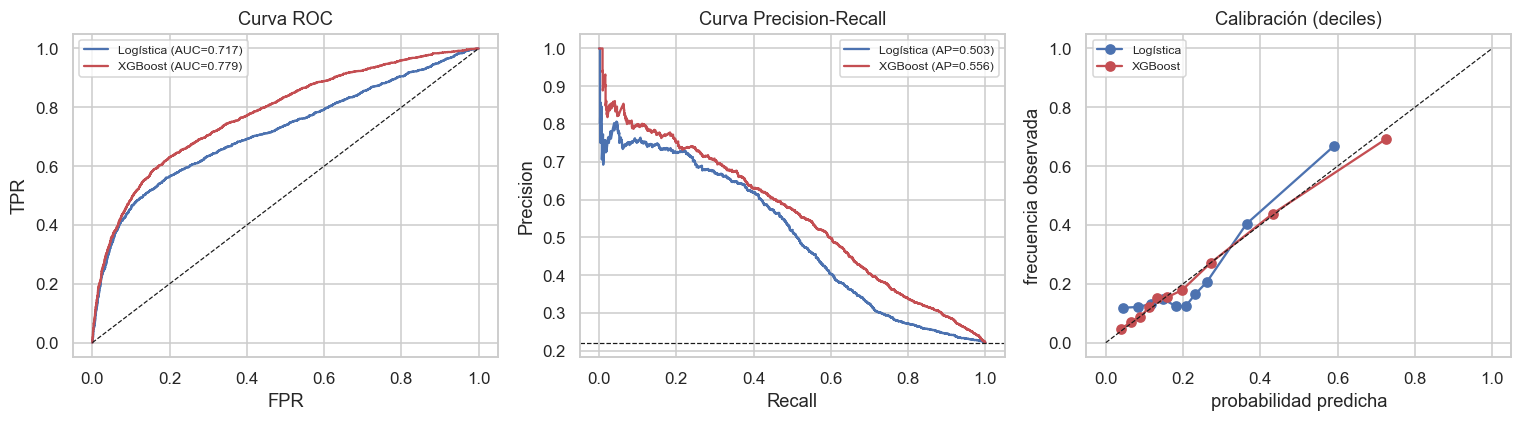

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for nombre, p, c in [("Logística", p_lr, PALETA["lr"]), ("XGBoost", p_xgb, PALETA["xgb"])]:
    fpr, tpr, _ = roc_curve(y_te, p)
    axes[0].plot(fpr, tpr, color=c, label=f"{nombre} (AUC={roc_auc_score(y_te, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, p)
    axes[1].plot(rc, pr, color=c, label=f"{nombre} (AP={average_precision_score(y_te, p):.3f})")
    # calibración
    bins = np.quantile(p, np.linspace(0, 1, 11))
    idx = np.clip(np.digitize(p, bins[1:-1]), 0, 9)
    obs = pd.Series(y_te.values).groupby(idx).mean()
    pred = pd.Series(p).groupby(idx).mean()
    axes[2].plot(pred, obs, "o-", color=c, label=nombre)

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(xlabel="FPR", ylabel="TPR", title="Curva ROC")
axes[1].axhline(y_te.mean(), ls="--", c="k", lw=0.8)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Curva Precision-Recall")
axes[2].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[2].set(xlabel="probabilidad predicha", ylabel="frecuencia observada", title="Calibración (deciles)")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout()
guardar_fig("04_rendimiento")

<a id="s6"></a>
## 6. Explicaciones SHAP (caso base)

Dos explicadores distintos, ambos **exactos** para su modelo y ambos en la escala de
*log-odds*, que es lo que hace comparables las magnitudes:

- `TreeExplainer` con `feature_perturbation="interventional"` para XGBoost (Lundberg
  et al., 2020). Se pasa el `background` explícitamente.
- `LinearExplainer` para la logística: en un modelo lineal el valor de Shapley tiene
  forma cerrada, $\phi_j(x) = \beta_j (x_j - E[x_j])$, así que la explicación es exacta y
  no aproximada.

> **Detalle de implementación con consecuencias.** Si al explicador se le pasa el
> *background* como DataFrame, `shap` lo submuestrea a 100 filas por defecto
> (`max_samples=100`) y solo lo avisa con un *warning*. Eso invalidaría el análisis 3,
> donde el tamaño del background es la variable de interés, así que se envuelve
> siempre en un `shap.maskers.Independent(..., max_samples=len(background))`.

In [20]:
def masker(background: pd.DataFrame) -> shap.maskers.Independent:
    """Envuelve el background en un masker que usa TODAS sus filas.

    Si se le pasa un DataFrame directamente, shap lo submuestrea a 100 filas por
    defecto (max_samples=100) y avisa solo con un warning. Eso invalidaría en
    silencio el análisis 3, donde el tamaño del background es justamente la
    variable de interés.
    """
    return shap.maskers.Independent(background, max_samples=len(background))


def explicador_xgb(modelo, background=None, perturbation="interventional"):
    if perturbation == "interventional":
        return shap.TreeExplainer(
            modelo, data=masker(background), feature_perturbation="interventional", model_output="raw"
        )
    return shap.TreeExplainer(modelo, feature_perturbation="tree_path_dependent")


def shap_xgb(modelo, X, background=None, perturbation="interventional") -> np.ndarray:
    return np.asarray(explicador_xgb(modelo, background, perturbation).shap_values(X))


def shap_lr(modelo, X, background) -> np.ndarray:
    expl = shap.LinearExplainer(modelo, masker(background))
    return np.asarray(expl.shap_values(X))


def base_lr(modelo, background) -> float:
    """Valor base de LinearSHAP, necesario para comprobar la eficiencia."""
    return float(np.ravel(shap.LinearExplainer(modelo, masker(background)).expected_value)[0])


t0 = time.time()
with sin_barra_de_progreso():
    sv_xgb = shap_xgb(modelo_xgb, X_expl, X_bg)
sv_lr = shap_lr(modelo_lr, X_expl, X_bg)
print(f"SHAP calculado en {time.time() - t0:.1f} s | shape: {sv_xgb.shape}")

SHAP calculado en 2.8 s | shape: (200, 26)


### 6.1 Comprobación de la propiedad de eficiencia

Los valores de Shapley deben sumar, junto al valor base, la salida del modelo para cada
cliente. Es la verificación de que la implementación es correcta; conviene incluirla en la
memoria como control.

In [21]:
base_xgb = explicador_xgb(modelo_xgb, X_bg).expected_value
logit_xgb = modelo_xgb.predict(X_expl, output_margin=True)
err = np.abs(sv_xgb.sum(axis=1) + base_xgb - logit_xgb).max()
print(f"Valor base (log-odds): {float(np.ravel(base_xgb)[0]):.4f}")
print(f"XGBoost  · error máximo |sum(SHAP) + base - logit| = {err:.2e}   ->  {'OK' if err < 1e-3 else 'REVISAR'}")

# La misma comprobación para LinearSHAP: el análisis 1 depende de que ambos estén en log-odds
base_lr_val = base_lr(modelo_lr, X_bg)
logit_lr = modelo_lr.decision_function(X_expl)
err_lr = np.abs(sv_lr.sum(axis=1) + base_lr_val - logit_lr).max()
print(f"Logística · error máximo |sum(SHAP) + base - logit| = {err_lr:.2e}   ->  {'OK' if err_lr < 1e-3 else 'REVISAR'}")

Valor base (log-odds): -1.5251
XGBoost  · error máximo |sum(SHAP) + base - logit| = 3.40e-06   ->  OK
Logística · error máximo |sum(SHAP) + base - logit| = 8.88e-16   ->  OK


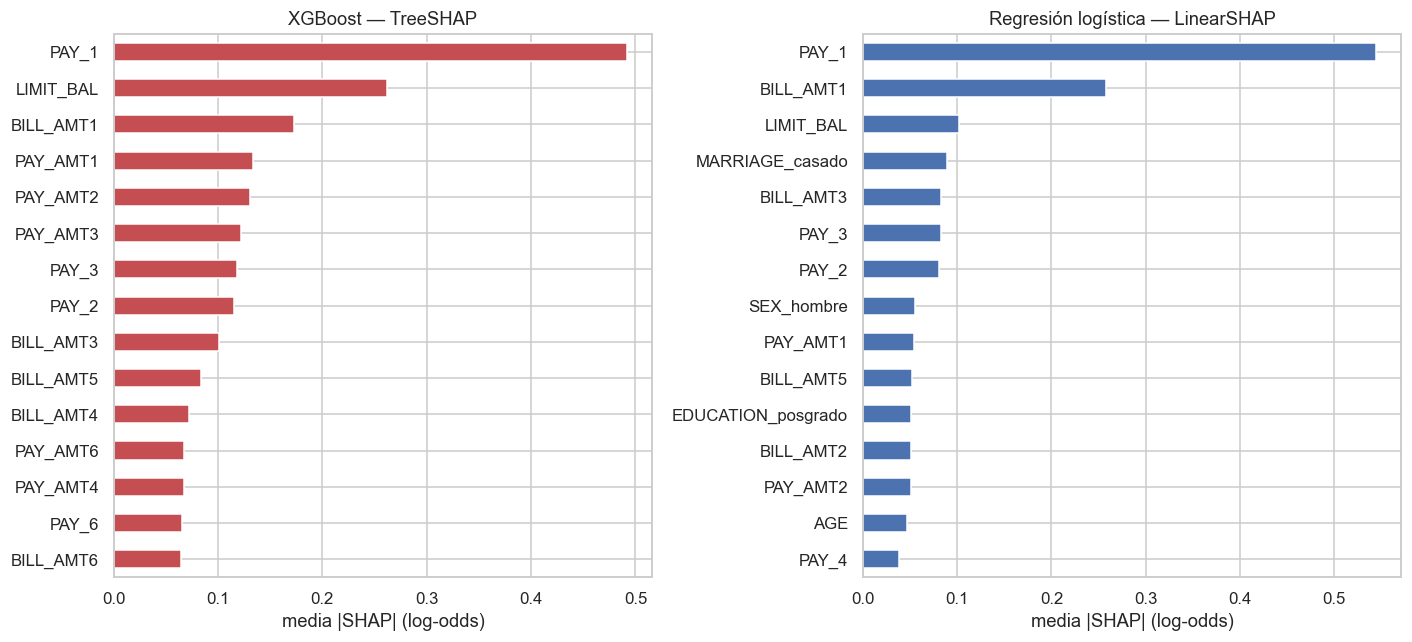

,media |SHAP| XGBoost
PAY_1,0.4916
LIMIT_BAL,0.2616
BILL_AMT1,0.1733
PAY_AMT1,0.1336
PAY_AMT2,0.1308
PAY_AMT3,0.1218
PAY_3,0.1179
PAY_2,0.1157
BILL_AMT3,0.1009
BILL_AMT5,0.0842


In [22]:
def importancia_global(sv: np.ndarray, features=FEATURES) -> pd.Series:
    """Importancia global = media del valor absoluto de las atribuciones locales."""
    return pd.Series(np.abs(sv).mean(axis=0), index=features)


imp_xgb = importancia_global(sv_xgb).sort_values(ascending=False)
imp_lr = importancia_global(sv_lr).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False)
imp_xgb.head(15)[::-1].plot.barh(ax=axes[0], color=PALETA["xgb"])
axes[0].set_title("XGBoost — TreeSHAP")
imp_lr.head(15)[::-1].plot.barh(ax=axes[1], color=PALETA["lr"])
axes[1].set_title("Regresión logística — LinearSHAP")
for a in axes:
    a.set_xlabel("media |SHAP| (log-odds)")
plt.tight_layout()
guardar_fig("05_importancia_global")

guardar_tabla(pd.DataFrame({"SHAP_xgb": imp_xgb, "SHAP_lr": imp_lr}).round(5), "importancia_global")
imp_xgb.head(10).round(4).to_frame("media |SHAP| XGBoost")

El conjunto de explicación está balanceado 50/50 a propósito, para que las 200 explicaciones
locales que se siguen a lo largo del trabajo contengan suficientes impagos. Pero la importancia
global es una media de `|SHAP|` sobre ese conjunto, así que hereda su composición: se calcula
sobre una cartera con un 50 % de impago, no con el 22 % real. Antes de usar el ranking como
descripción del modelo hay que comprobar que no es un artefacto del balanceo.

In [23]:
N_NATURAL = 500
X_nat = X_te.sample(n=min(N_NATURAL, len(X_te)), random_state=SEED + 7)
with sin_barra_de_progreso():
    sv_nat_xgb = shap_xgb(modelo_xgb, X_nat, X_bg)
sv_nat_lr = shap_lr(modelo_lr, X_nat, X_bg)

imp_nat_xgb = importancia_global(sv_nat_xgb).sort_values(ascending=False)
imp_nat_lr = importancia_global(sv_nat_lr).sort_values(ascending=False)
print(f"Muestra con distribucion natural: {X_nat.shape} (tasa impago {y_te.loc[X_nat.index].mean():.3f}) "
      f"frente al conjunto explicado ({y_expl.mean():.3f})")

filas = []
for nombre, bal, nat in [("XGBoost", imp_xgb, imp_nat_xgb), ("Logistica", imp_lr, imp_nat_lr)]:
    comun = bal.index
    filas.append({
        "modelo": nombre,
        "Spearman(balanceado, natural)": stats.spearmanr(bal.values, nat.reindex(comun).values).statistic,
        "coincidencias top-5": len(set(bal.head(5).index) & set(nat.head(5).index)),
        "coincidencias top-10": len(set(bal.head(10).index) & set(nat.head(10).index)),
        "misma variable dominante": bal.index[0] == nat.index[0],
    })
comp_balanceo = pd.DataFrame(filas).set_index("modelo").round(4)
print()
print(comp_balanceo.to_string())
guardar_tabla(comp_balanceo, "importancia_balanceo")

Muestra con distribucion natural: (500, 26) (tasa impago 0.224) frente al conjunto explicado (0.500)

           Spearman(balanceado, natural)  coincidencias top-5  coincidencias top-10  misma variable dominante
modelo                                                                                                       
XGBoost                           0.9945                    5                    10                      True
Logistica                         0.9836                    5                     9                      True


,"Spearman(balanceado, natural)",coincidencias top-5,coincidencias top-10,misma variable dominante
modelo,,,,
XGBoost,0.9945,5,10,True
Logistica,0.9836,5,9,True


El ranking se reporta sobre el conjunto balanceado por coherencia con el resto del trabajo (es el
mismo conjunto en los cuatro análisis), y la comparación anterior es la justificación de que esa
elección no cambia la lectura. Sí cambia la **escala**: con más impagos en la muestra, las
atribuciones son mayores en valor absoluto. Por eso todas las comparaciones entre modelos y entre
variantes se hacen sobre rangos o sobre similitudes del coseno, que no dependen de esa escala.

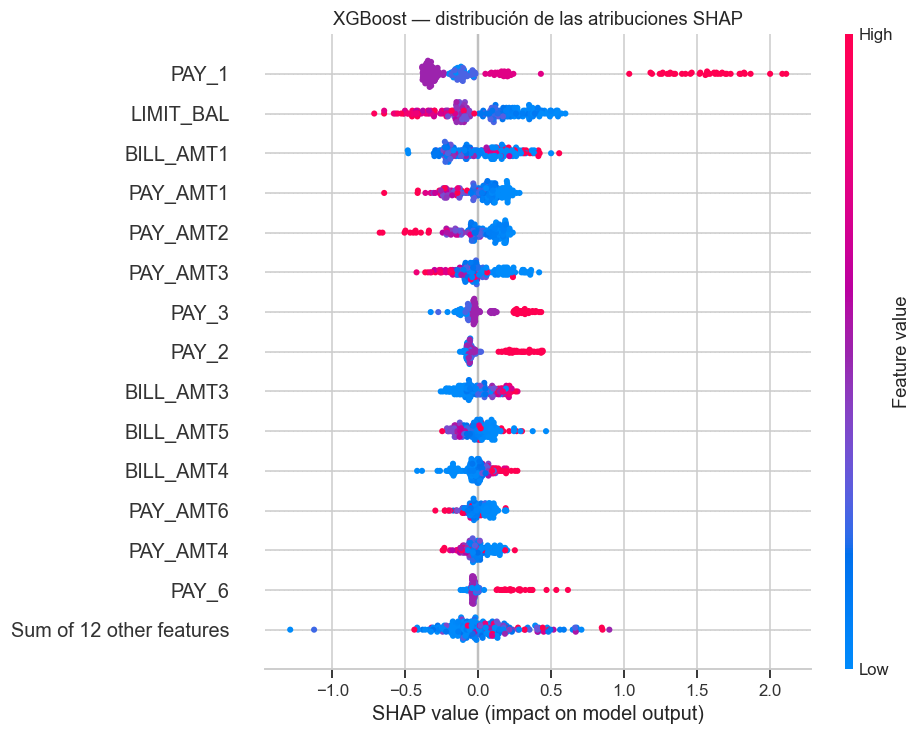

In [24]:
# Beeswarm: dirección y dispersión del efecto de cada variable
expl_obj = shap.Explanation(
    values=sv_xgb, base_values=np.repeat(float(np.ravel(base_xgb)[0]), len(X_expl)),
    data=X_expl.values, feature_names=FEATURES,
)
shap.plots.beeswarm(expl_obj, max_display=15, show=False)
plt.title("XGBoost — distribución de las atribuciones SHAP")
guardar_fig("06_beeswarm")

Cliente 10023 | p(impago) = 0.855 | real = 0
Es un FALSO POSITIVO: el modelo le asigna la probabilidad mas alta de toda la muestra
y el cliente no impago. Se mantiene como ejemplo justamente por eso: es el caso en el
que una explicacion equivocada tiene consecuencias reales para una persona, y el que
acabaria en una reclamacion. La explicacion describe por que el modelo decidio lo que
decidio, no por que el cliente vaya a impagar.


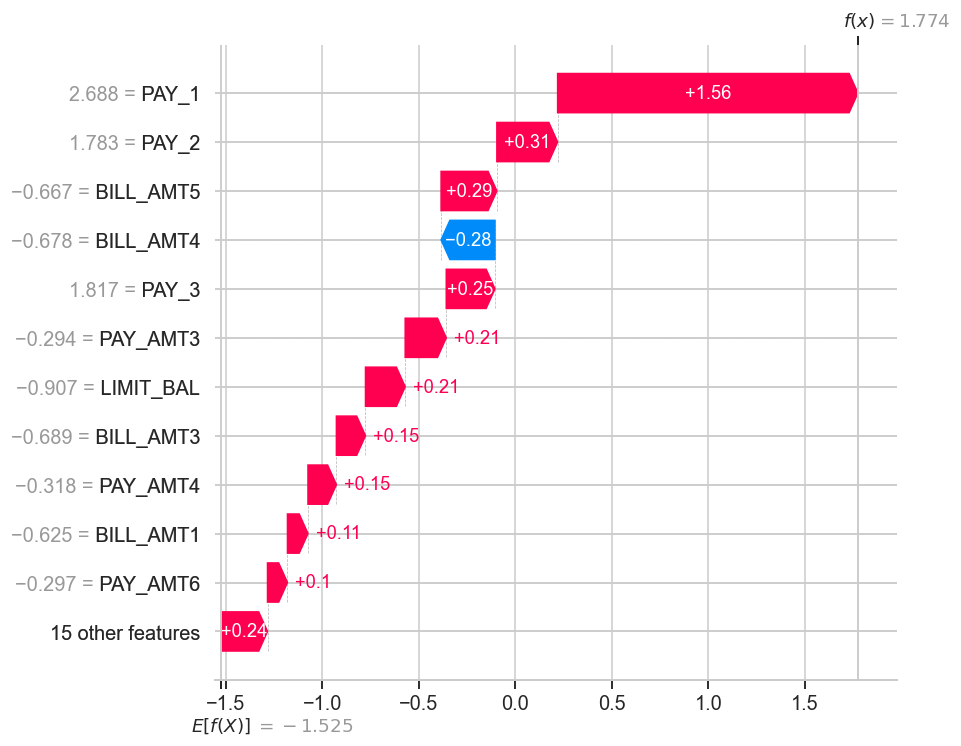

In [25]:
# Explicación local de un cliente concreto: el caso de uso que motiva todo el trabajo.
# Se elige el de mayor probabilidad estimada, que es el caso donde una denegación seria mas
# probable y donde, por tanto, la explicacion tendria que sostenerse ante el cliente.
i_cliente = int(np.argmax(modelo_xgb.predict_proba(X_expl)[:, 1]))
p_cliente = modelo_xgb.predict_proba(X_expl)[i_cliente, 1]
print(f"Cliente {X_expl.index[i_cliente]} | p(impago) = {p_cliente:.3f} | real = {y_expl.iloc[i_cliente]}")
if y_expl.iloc[i_cliente] == 0:
    print("Es un FALSO POSITIVO: el modelo le asigna la probabilidad mas alta de toda la muestra\n"
          "y el cliente no impago. Se mantiene como ejemplo justamente por eso: es el caso en el\n"
          "que una explicacion equivocada tiene consecuencias reales para una persona, y el que\n"
          "acabaria en una reclamacion. La explicacion describe por que el modelo decidio lo que\n"
          "decidio, no por que el cliente vaya a impagar.")
shap.plots.waterfall(expl_obj[i_cliente], max_display=12, show=False)
guardar_fig("07_waterfall_cliente")

<a id="s7"></a>
## 7. Análisis 1 — Concordancia entre la logística y SHAP-XGBoost

Lin y Wang (2025) no comparan con ningún otro modelo. Estabilidad no implica corrección, y
comparar con otro modelo tampoco la demuestra, pero la logística aporta dos cosas: una
**línea base de estabilidad** y una **comprobación de validez convergente**. Donde ambos
modelos coinciden hay indicio de señal real; donde discrepan se localiza estructura no
lineal o interacciones que la logística no puede representar.

Este análisis tiene menos peso que los análisis 2 y 3. Sirve, por un lado, como
comprobación de la implementación: una concordancia casi nula o signos invertidos en las
variables dominantes indicarían un fallo en el montaje experimental, no un hallazgo sobre
SHAP. Por otro, como diagnóstico dirigido por hipótesis, contrastando si la discrepancia se
concentra donde es esperable. Para clasificar las variables sin recurrir al propio SHAP se
usa un XGBoost aditivo (árboles de profundidad 1) como modelo intermedio, en el apartado 7.3.

Se comparan las dos explicaciones en tres planos:

1. **Ranking global**: correlación de Spearman y τ de Kendall entre las importancias, y
   solapamiento de los *top-k*.
2. **Signo del efecto**: dirección con la que cada variable empuja la predicción.
3. **Explicaciones locales**: cliente a cliente, ¿apuntan las dos al mismo motivo?

Interesa tanto dónde coinciden como dónde no: las discrepancias localizan justamente las
no linealidades e interacciones que la logística no puede captar.

In [26]:
def solapamiento_topk(a: pd.Series, b: pd.Series, k: int = TOP_K) -> dict:
    ta, tb = set(a.nlargest(k).index), set(b.nlargest(k).index)
    return {
        "coincidencias": len(ta & tb),
        "jaccard": len(ta & tb) / len(ta | tb),
        "solo_A": sorted(ta - tb),
        "solo_B": sorted(tb - ta),
    }


imp_lr_al = imp_lr.reindex(imp_xgb.index)  # mismo orden de variables

# Se reportan como descriptivos: el p-valor de Spearman supone observaciones independientes y
# aquí son las 26 importancias de los mismos dos modelos, así que no procede.
rho = stats.spearmanr(imp_xgb.values, imp_lr_al.values).statistic
tau = stats.kendalltau(imp_xgb.values, imp_lr_al.values).statistic
sol = solapamiento_topk(imp_xgb, imp_lr)

print(f"Spearman entre importancias globales: rho = {rho:.3f}")
print(f"Kendall tau:                          tau = {tau:.3f}")
print(f"Top-{TOP_K}: {sol['coincidencias']}/{TOP_K} coincidencias (Jaccard = {sol['jaccard']:.2f})")
print(f"  solo en XGBoost:  {sol['solo_A']}")
print(f"  solo en logística: {sol['solo_B']}")

Spearman entre importancias globales: rho = 0.480
Kendall tau:                          tau = 0.354
Top-5: 3/5 coincidencias (Jaccard = 0.43)
  solo en XGBoost:  ['PAY_AMT1', 'PAY_AMT2']
  solo en logística: ['BILL_AMT3', 'MARRIAGE_casado']


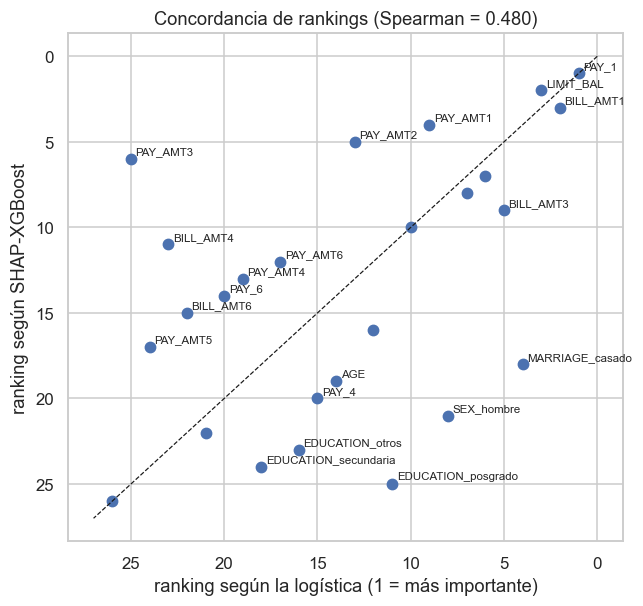

,rank_xgb,rank_lr,imp_xgb,imp_lr
PAY_1,1.0,1.0,0.492,0.544
LIMIT_BAL,2.0,3.0,0.262,0.102
BILL_AMT1,3.0,2.0,0.173,0.258
PAY_AMT1,4.0,9.0,0.134,0.055
PAY_AMT2,5.0,13.0,0.131,0.051
PAY_AMT3,6.0,25.0,0.122,0.005
PAY_3,7.0,6.0,0.118,0.083
PAY_2,8.0,7.0,0.116,0.081
BILL_AMT3,9.0,5.0,0.101,0.083
BILL_AMT5,10.0,10.0,0.084,0.052


In [27]:
comp = pd.DataFrame({
    "rank_xgb": imp_xgb.rank(ascending=False),
    "rank_lr": imp_lr_al.rank(ascending=False),
    "imp_xgb": imp_xgb,
    "imp_lr": imp_lr_al,
})

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(comp["rank_lr"], comp["rank_xgb"], s=45, color="#4C72B0")
lim = len(FEATURES) + 1
ax.plot([0, lim], [0, lim], "k--", lw=0.8)
for var, r in comp.iterrows():
    if abs(r["rank_xgb"] - r["rank_lr"]) >= 5 or min(r["rank_xgb"], r["rank_lr"]) <= TOP_K:
        ax.annotate(var, (r["rank_lr"], r["rank_xgb"]), fontsize=7.5,
                    xytext=(3, 3), textcoords="offset points")
ax.set(xlabel="ranking según la logística (1 = más importante)",
       ylabel="ranking según SHAP-XGBoost",
       title=f"Concordancia de rankings (Spearman = {rho:.3f})")
ax.invert_xaxis(); ax.invert_yaxis()
guardar_fig("08_concordancia_rankings")

guardar_tabla(comp.sort_values("rank_xgb").round(4), "concordancia_rankings")
comp.sort_values("rank_xgb").head(10).round(3)

### 7.1 Dirección del efecto

El signo se estima como la correlación de Spearman entre el valor de la variable y su
atribución SHAP en el conjunto de explicación. En la logística coincide por construcción
con el signo del coeficiente; en XGBoost puede ser ambiguo si el efecto no es monótono,
y ese es precisamente uno de los resultados interesantes.

In [28]:
def signo_efecto(sv: np.ndarray, X: pd.DataFrame) -> pd.Series:
    """Signo del efecto: correlación entre el valor de la variable y su atribución.

    Devuelve NaN si la variable es constante en la muestra, en cuyo caso no hay signo que
    comparar. Esos casos se excluyen explícitamente al contar coincidencias, porque
    np.sign(NaN) == np.sign(NaN) es False y se colarían como discrepancia.
    """
    out = {}
    for j, f in enumerate(X.columns):
        x = X[f].values
        if np.std(x) == 0:
            out[f] = np.nan
            continue
        out[f] = stats.spearmanr(x, sv[:, j]).statistic
    return pd.Series(out)


sig_xgb = signo_efecto(sv_xgb, X_expl)
sig_lr = signo_efecto(sv_lr, X_expl)

tabla_signos = pd.DataFrame({
    "corr_valor_shap_xgb": sig_xgb,
    "corr_valor_shap_lr": sig_lr,          # ±1 por construcción: el modelo es lineal
    "coef_logistica": pd.Series(modelo_lr.coef_[0], index=FEATURES),
    "|beta|·SD(x)": (beta.abs() * sd_x),
}).assign(
    mismo_signo=lambda d: np.sign(d["corr_valor_shap_xgb"]) == np.sign(d["corr_valor_shap_lr"])
).loc[imp_xgb.index]

# Solo se cuentan las variables donde ambos modelos tienen un signo definido. Además se
# reporta aparte el top-10, porque un coeficiente casi nulo (BILL_AMT4, beta = -0,008) da un
# signo de LinearSHAP igual de rotundo que uno grande, y contarlo como afirmación direccional
# infla tanto los aciertos como las discrepancias.
definidas = tabla_signos[["corr_valor_shap_xgb", "corr_valor_shap_lr"]].notna().all(axis=1)
tabla_signos = tabla_signos[definidas]
n_ok = int(tabla_signos["mismo_signo"].sum())
print(f"Variables con signo definido en ambos modelos: {len(tabla_signos)}/{len(FEATURES)}")
print(f"De ellas, mismo signo: {n_ok}")
print("Discrepancias:", list(tabla_signos.index[~tabla_signos["mismo_signo"]]))

top10 = [v for v in imp_xgb.head(10).index if v in tabla_signos.index]
n_ok10 = int(tabla_signos.loc[top10, "mismo_signo"].sum())
print(f"\nEntre las 10 más importantes para XGBoost: {n_ok10}/{len(top10)} coinciden")
print("Discrepancias en el top-10:",
      [v for v in top10 if not tabla_signos.loc[v, "mismo_signo"]])

guardar_tabla(tabla_signos.round(4), "signos_efecto")
tabla_signos.head(12).round(3)

Variables con signo definido en ambos modelos: 26/26
De ellas, mismo signo: 23
Discrepancias: ['BILL_AMT5', 'BILL_AMT4', 'BILL_AMT6']

Entre las 10 más importantes para XGBoost: 9/10 coinciden
Discrepancias en el top-10: ['BILL_AMT5']


,corr_valor_shap_xgb,corr_valor_shap_lr,coef_logistica,|beta|·SD(x),mismo_signo
PAY_1,0.487,1.0,0.650,0.650,True
LIMIT_BAL,-0.941,-1.0,-0.117,0.117,True
BILL_AMT1,-0.246,-1.0,-0.330,0.330,True
PAY_AMT1,-0.912,-1.0,-0.187,0.187,True
PAY_AMT2,-0.865,-1.0,-0.214,0.214,True
PAY_AMT3,-0.724,-1.0,-0.018,0.018,True
PAY_3,0.937,1.0,0.096,0.096,True
PAY_2,0.636,1.0,0.099,0.099,True
BILL_AMT3,0.803,1.0,0.104,0.104,True
BILL_AMT5,-0.743,1.0,0.067,0.067,False


### 7.2 Concordancia local, cliente a cliente

Una correlación global alta puede esconder discrepancias en clientes individuales, que es
el nivel al que se toma la decisión de crédito. Se mide con la similitud del coseno entre
los dos vectores de atribución del mismo cliente.

Similitud del coseno local: mediana 0.489 | p10 0.063 | p90 0.957
Coincide la variable más determinante en el 30.5 % de los clientes


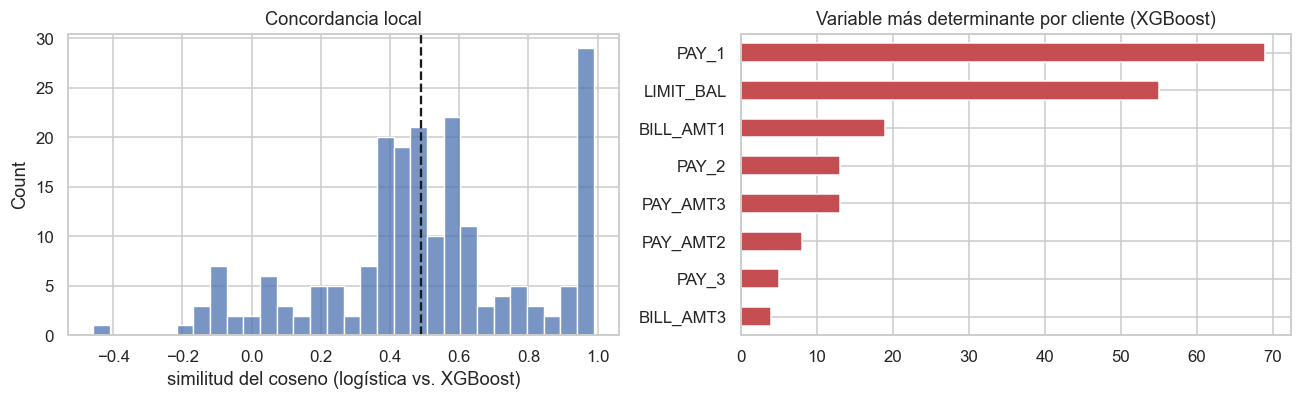

In [29]:
def cos_sim(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    na = np.linalg.norm(A, axis=1)
    nb = np.linalg.norm(B, axis=1)
    denom = np.where((na * nb) == 0, 1e-12, na * nb)
    return (A * B).sum(axis=1) / denom


cos_local = cos_sim(sv_xgb, sv_lr)

# ¿coincide la variable señalada como principal motivo?
top1_xgb = np.array(FEATURES)[np.argmax(np.abs(sv_xgb), axis=1)]
top1_lr = np.array(FEATURES)[np.argmax(np.abs(sv_lr), axis=1)]
coincide_top1 = (top1_xgb == top1_lr).mean()

print(f"Similitud del coseno local: mediana {np.median(cos_local):.3f} | "
      f"p10 {np.percentile(cos_local, 10):.3f} | p90 {np.percentile(cos_local, 90):.3f}")
print(f"Coincide la variable más determinante en el {100 * coincide_top1:.1f} % de los clientes")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(cos_local, bins=30, ax=axes[0], color="#4C72B0")
axes[0].axvline(np.median(cos_local), ls="--", c="k")
axes[0].set(xlabel="similitud del coseno (logística vs. XGBoost)", title="Concordancia local")
pd.Series(top1_xgb).value_counts().head(8)[::-1].plot.barh(ax=axes[1], color=PALETA["xgb"])
axes[1].set(title="Variable más determinante por cliente (XGBoost)")
plt.tight_layout()
guardar_fig("09_concordancia_local")

### 7.3 De dónde viene la discrepancia: modelo aditivo intermedio

La concordancia entre la logística y SHAP-XGBoost mezcla tres causas: no linealidad,
interacciones y, si se usaran los coeficientes crudos, el artefacto de escala del apartado 4. La
tercera ya está resuelta (se usa SHAP sobre la logística, no los coeficientes). Las otras dos se
separan con un **modelo intermedio**: un XGBoost de profundidad 1, que puede curvar el efecto de
cada variable pero no puede combinar dos variables.

Así, la diferencia entre la logística y el aditivo aísla la no linealidad, y la diferencia entre
el aditivo y el XGBoost completo aísla las interacciones. Ninguna de las dos medidas usa valores
SHAP, de modo que sirven para explicar la discrepancia sin apoyarse en lo que se quiere explicar.

In [30]:
# Mismo entrenamiento que el modelo completo, pero con árboles de un solo corte
PARAMS_ADITIVO = dict(XGB_PARAMS)
PARAMS_ADITIVO["max_depth"] = 1

t0 = time.time()
modelo_add = xgb.XGBClassifier(random_state=SEED, **PARAMS_ADITIVO).fit(X_tr, y_tr)
print(f"XGBoost aditivo entrenado en {time.time() - t0:.1f} s")

margen_lr = modelo_lr.decision_function(X_te)
margen_add = modelo_add.predict(X_te, output_margin=True)
margen_full = modelo_xgb.predict(X_te, output_margin=True)

rend = pd.DataFrame({
    "ROC-AUC": [roc_auc_score(y_te, margen_lr), roc_auc_score(y_te, margen_add),
                roc_auc_score(y_te, margen_full)],
}, index=["Logística", "XGBoost aditivo", "XGBoost completo"]).round(4)
print()
print(rend.to_string())

# Peso de las interacciones: lo que el modelo completo añade sobre el aditivo
r_add_full = stats.spearmanr(margen_add, margen_full).statistic
sd_ratio = np.std(margen_full - margen_add) / np.std(margen_full)
print(f"\nInteracciones: Spearman(aditivo, completo) = {r_add_full:.3f} | "
      f"sd(completo - aditivo) / sd(completo) = {sd_ratio:.3f}")

XGBoost aditivo entrenado en 0.3 s

                  ROC-AUC
Logística          0.7175
XGBoost aditivo    0.7727
XGBoost completo   0.7789

Interacciones: Spearman(aditivo, completo) = 0.926 | sd(completo - aditivo) / sd(completo) = 0.360


Con el aditivo entrenado, la no linealidad de cada variable se mide comparando su curva de efecto
con la recta de la logística. En un modelo de profundidad 1 el efecto de cada variable es una
función escalonada bien definida, que se obtiene por dependencia parcial: se recorre una rejilla
de valores de la variable manteniendo el resto como está y se promedia el margen. Como el modelo
no tiene interacciones, esa curva **es** el efecto de la variable, no una aproximación.

La comparación se hace en log-odds, que es la escala en la que también está el coeficiente de la
logística.

In [31]:
N_PDP, N_REJILLA = 500, 11
X_pdp = X_te.sample(n=min(N_PDP, len(X_te)), random_state=SEED)


def curva_efecto(modelo, var: str) -> tuple[np.ndarray, np.ndarray]:
    """Dependencia parcial en log-odds sobre una rejilla de cuantiles de la variable."""
    valores = np.unique(np.quantile(X_te[var], np.linspace(0.02, 0.98, N_REJILLA)))
    efecto = []
    for v in valores:
        Xv = X_pdp.copy()
        Xv[var] = v
        efecto.append(modelo.predict(Xv, output_margin=True).mean())
    efecto = np.asarray(efecto)
    return valores, efecto - efecto.mean()


filas = []
for var in imp_xgb.head(15).index:
    v, curva_add = curva_efecto(modelo_add, var)
    if len(v) < 3 or np.allclose(curva_add, 0):
        continue
    # Recta de la logística sobre esa misma rejilla, también centrada
    recta = beta[var] * v
    recta = recta - recta.mean()
    # Parte de la curva que una recta no explica
    pend = np.polyfit(v, curva_add, 1)
    residuo = curva_add - np.polyval(pend, v)
    no_lineal = float(np.sum(residuo ** 2) / max(np.sum(curva_add ** 2), 1e-12))
    filas.append({
        "variable": var,
        "amplitud del efecto": float(curva_add.max() - curva_add.min()),
        "no linealidad": no_lineal,
        "dist. a la recta de la logística": float(np.sqrt(np.mean((curva_add - recta) ** 2))),
    })

no_lin = pd.DataFrame(filas).set_index("variable").sort_values("no linealidad", ascending=False)
print("Cuánto se aparta de una recta el efecto de cada variable en el modelo aditivo:")
print(no_lin.round(3).to_string())
guardar_tabla(no_lin.round(4), "no_linealidad_aditivo")

Cuánto se aparta de una recta el efecto de cada variable en el modelo aditivo:
           amplitud del efecto  no linealidad  dist. a la recta de la logística
variable                                                                       
PAY_AMT4                 0.110          0.847                             0.041
PAY_AMT6                 0.140          0.771                             0.044
PAY_AMT3                 0.268          0.692                             0.075
BILL_AMT1                0.236          0.409                             0.422
PAY_AMT1                 0.351          0.330                             0.071
PAY_1                    1.918          0.310                             0.458
BILL_AMT4                0.016          0.250                             0.015
PAY_2                    0.278          0.229                             0.060
PAY_6                    0.274          0.229                             0.103
BILL_AMT6                0.026          0

,amplitud del efecto,no linealidad,dist. a la recta de la logística
variable,,,
PAY_AMT4,0.1102,0.8473,0.0411
PAY_AMT6,0.1405,0.7709,0.0441
PAY_AMT3,0.2679,0.6915,0.0751
BILL_AMT1,0.2362,0.4086,0.4223
PAY_AMT1,0.3510,0.3303,0.0713
PAY_1,1.9181,0.3101,0.4581
BILL_AMT4,0.0163,0.2498,0.0147
PAY_2,0.2775,0.2286,0.0599
PAY_6,0.2736,0.2286,0.1025


Spearman(no linealidad, discrepancia de ranking entre modelos) = +0.182


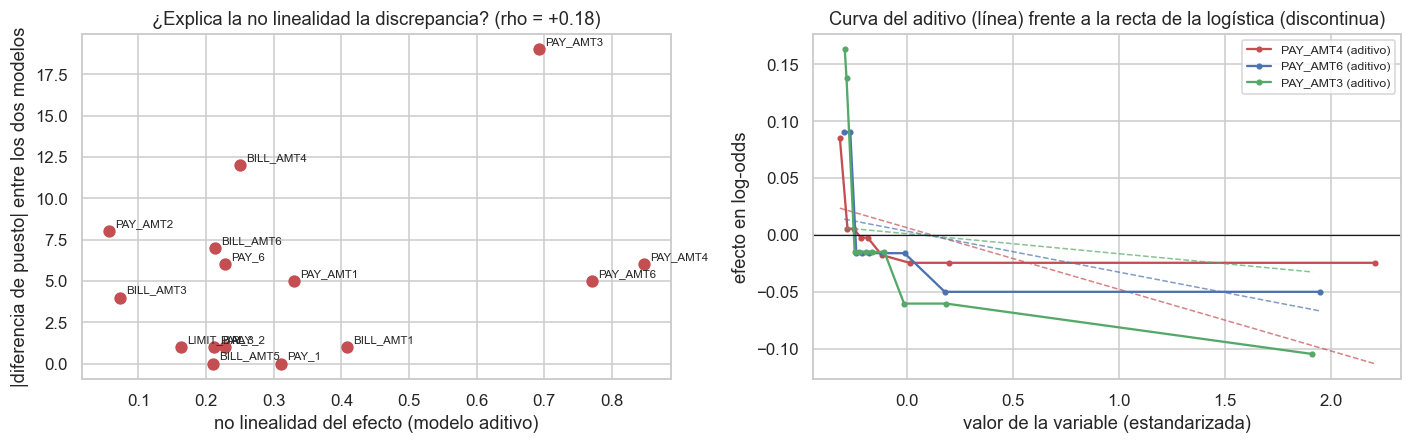

In [32]:
# ¿Se concentra la discrepancia entre modelos donde el aditivo dice que hay no linealidad?
disc = (imp_xgb.rank(ascending=False) - imp_lr_al.rank(ascending=False)).abs()
comp_nl = no_lin.assign(discrepancia_ranking=disc.reindex(no_lin.index)).dropna()
rho_nl = stats.spearmanr(comp_nl["no linealidad"], comp_nl["discrepancia_ranking"]).statistic
print(f"Spearman(no linealidad, discrepancia de ranking entre modelos) = {rho_nl:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(comp_nl["no linealidad"], comp_nl["discrepancia_ranking"], s=50, color=PALETA["xgb"])
for var, r in comp_nl.iterrows():
    axes[0].annotate(var, (r["no linealidad"], r["discrepancia_ranking"]), fontsize=7.5,
                     xytext=(4, 3), textcoords="offset points")
axes[0].set(xlabel="no linealidad del efecto (modelo aditivo)",
            ylabel="|diferencia de puesto| entre los dos modelos",
            title=f"¿Explica la no linealidad la discrepancia? (rho = {rho_nl:+.2f})")

for var, color in zip(comp_nl.head(3).index, ["#C44E52", "#4C72B0", "#55A868"]):
    v, c = curva_efecto(modelo_add, var)
    axes[1].plot(v, c, "o-", ms=3, color=color, label=f"{var} (aditivo)")
    recta = beta[var] * v
    axes[1].plot(v, recta - recta.mean(), "--", lw=1, color=color, alpha=0.7)
axes[1].axhline(0, c="k", lw=0.8)
axes[1].set(xlabel="valor de la variable (estandarizada)", ylabel="efecto en log-odds",
            title="Curva del aditivo (línea) frente a la recta de la logística (discontinua)")
axes[1].legend(fontsize=8)
plt.tight_layout()
guardar_fig("09b_no_linealidad_aditivo")

Lectura del apartado. Si la discrepancia entre los dos modelos se concentrase en las variables
que el aditivo señala como no lineales, sería atribuible a la estructura del problema y no al
método de atribución. Si apareciera en variables de efecto prácticamente recto, habría que buscar
otra explicación, y el primer candidato sería la dependencia entre variables que señalan Aas et
al. (2021): en este dataset las seis `BILL_AMT` están fuertemente correlacionadas entre sí, y ese
es justamente el bloque donde el análisis 1 detecta las discrepancias de signo.

<a id="s8"></a>
## 8. Análisis 2 — Estabilidad ante el reentrenamiento

Se reentrenan los dos modelos `N_REPEATS` veces variando **a la vez la semilla y la
submuestra de entrenamiento** (bootstrap). Esto amplía el diseño de Lin y Wang (2025),
que solo cambian la semilla manteniendo los mismos datos.

Puntos fijos del diseño (importantes para que la variabilidad medida sea atribuible al
reentrenamiento y no a otra cosa):

- el **conjunto de test** y los **clientes explicados** no cambian,
- el **conjunto de referencia** de SHAP no cambia (su efecto se aísla en el análisis 3),
- los **hiperparámetros** no cambian.

Se miden dos niveles de estabilidad: **global** (¿es estable el ranking de importancia?) y
**local** (¿recibe el mismo cliente la misma explicación?). El segundo es el que corresponde
al caso de uso real y el que Lin y Wang dejan fuera; Chen et al. (2024) y Ballegeer et al.
(2025) sí lo miden por instancia, pero remuestreando el entrenamiento a tasas de impago
forzadas entre el 1 % y el 30 %, mientras que aquí se usa bootstrap a la tasa nativa y se
compara además con la línea base cliente a cliente.

In [33]:
def repetir_entrenamientos(n_repeats=N_REPEATS, verbose=True):
    """Reentrena ambos modelos con bootstrap + semilla distinta y guarda las explicaciones."""
    n_tr = len(X_tr)
    n_boot = int(BOOTSTRAP_FRAC * n_tr)
    res = {
        "xgb": {"local": [], "auc": []},
        "lr": {"local": [], "auc": []},
    }
    t0 = time.time()
    for r in range(n_repeats):
        rs = np.random.default_rng(SEED + r)
        idx = rs.choice(n_tr, size=n_boot, replace=True)
        Xb, yb = X_tr.iloc[idx], y_tr.iloc[idx]

        m_x = entrenar_xgb(Xb, yb, seed=SEED + r)
        m_l = entrenar_lr(Xb, yb, seed=SEED + r)

        res["xgb"]["local"].append(shap_xgb(m_x, X_expl, X_bg))
        res["lr"]["local"].append(shap_lr(m_l, X_expl, X_bg))
        res["xgb"]["auc"].append(roc_auc_score(y_te, m_x.predict_proba(X_te)[:, 1]))
        res["lr"]["auc"].append(roc_auc_score(y_te, m_l.predict_proba(X_te)[:, 1]))

        if verbose and (r + 1) % 5 == 0:
            print(f"  repetición {r + 1}/{n_repeats}  ({time.time() - t0:.0f} s)")

    for k in res:
        res[k]["local"] = np.stack(res[k]["local"])                    # (R, N, F)
        res[k]["global"] = np.abs(res[k]["local"]).mean(axis=1)        # (R, F)
    print(f"Completado en {time.time() - t0:.0f} s")
    return res


with sin_barra_de_progreso():
    rep = repetir_entrenamientos()
print("Tensor de explicaciones locales:", rep["xgb"]["local"].shape, "(repeticiones, clientes, variables)")

  repetición 5/100  (16 s)


  repetición 10/100  (34 s)


  repetición 15/100  (51 s)


  repetición 20/100  (69 s)


  repetición 25/100  (86 s)


...

  repetición 80/100  (273 s)


  repetición 85/100  (290 s)


  repetición 90/100  (307 s)


  repetición 95/100  (324 s)


  repetición 100/100  (341 s)
Completado en 341 s
Tensor de explicaciones locales: (100, 200, 26) (repeticiones, clientes, variables)


In [34]:
print("AUC en test a lo largo de las repeticiones:")
for k, nom in [("lr", "Logística"), ("xgb", "XGBoost")]:
    a = np.array(rep[k]["auc"])
    print(f"  {nom:<10} media {a.mean():.4f} | sd {a.std():.5f} | rango [{a.min():.4f}, {a.max():.4f}]")

AUC en test a lo largo de las repeticiones:
  Logística  media 0.7168 | sd 0.00152 | rango [0.7122, 0.7196]
  XGBoost    media 0.7722 | sd 0.00187 | rango [0.7678, 0.7758]


### 8.1 Estabilidad global: W de Kendall y coeficiente de variación

El **W de Kendall** mide la concordancia entre los rankings de importancia producidos por
las repeticiones (0 = ninguna, 1 = idénticos); es la medida de Lin y Wang (2025). El
**coeficiente de variación** por variable, usado por Chen et al. (2024), permite ver
*qué* variables son las inestables, que es lo que el W agregado esconde.

In [35]:
def kendall_w(mat: np.ndarray) -> float:
    """W de Kendall. Filas = repeticiones (jueces), columnas = variables (ítems).

    Los empates se resuelven con rangos medios; no se aplica corrección por empates
    porque las importancias son continuas y los empates exactos son improbables.
    """
    R, n = mat.shape
    rangos = np.apply_along_axis(stats.rankdata, 1, mat)
    S = ((rangos.sum(axis=0) - rangos.sum() / n) ** 2).sum()
    return float(12 * S / (R**2 * (n**3 - n)))


def resumen_estabilidad_global(G: np.ndarray, features=FEATURES, k=TOP_K) -> tuple[float, pd.DataFrame]:
    W = kendall_w(G)
    media = G.mean(axis=0)
    cv = G.std(axis=0) / np.where(media == 0, np.nan, media)
    rangos = np.apply_along_axis(lambda v: stats.rankdata(-v), 1, G)   # 1 = más importante
    top_k_freq = (rangos <= k).mean(axis=0)
    d = pd.DataFrame({
        "imp_media": media,
        "imp_sd": G.std(axis=0),
        "CV": cv,
        "rank_medio": rangos.mean(axis=0),
        "rank_sd": rangos.std(axis=0),
        f"frec_top{k}": top_k_freq,
    }, index=features).sort_values("imp_media", ascending=False)
    return W, d


W_xgb, est_xgb = resumen_estabilidad_global(rep["xgb"]["global"])
W_lr, est_lr = resumen_estabilidad_global(rep["lr"]["global"])

print(f"W de Kendall — XGBoost (TreeSHAP): {W_xgb:.4f}")
print(f"W de Kendall — Regresión logística: {W_lr:.4f}")

guardar_tabla(est_xgb.round(4), "estabilidad_global_xgb")
guardar_tabla(est_lr.round(4), "estabilidad_global_lr")
est_xgb.head(12).round(3)

W de Kendall — XGBoost (TreeSHAP): 0.8584
W de Kendall — Regresión logística: 0.7009


,imp_media,imp_sd,CV,rank_medio,rank_sd,frec_top5
PAY_1,0.494,0.026,0.053,1.00,0.000,1.00
LIMIT_BAL,0.270,0.028,0.105,2.00,0.000,1.00
BILL_AMT1,0.188,0.025,0.130,3.41,0.776,0.97
PAY_AMT1,0.151,0.025,0.167,5.42,2.127,0.63
PAY_AMT2,0.137,0.026,0.190,6.40,2.445,0.40
PAY_AMT3,0.128,0.022,0.170,7.09,2.324,0.28
PAY_2,0.122,0.025,0.200,8.03,2.755,0.21
BILL_AMT3,0.119,0.034,0.290,8.86,4.113,0.24
PAY_3,0.103,0.022,0.210,10.33,3.237,0.05
BILL_AMT5,0.094,0.030,0.314,11.92,4.331,0.06


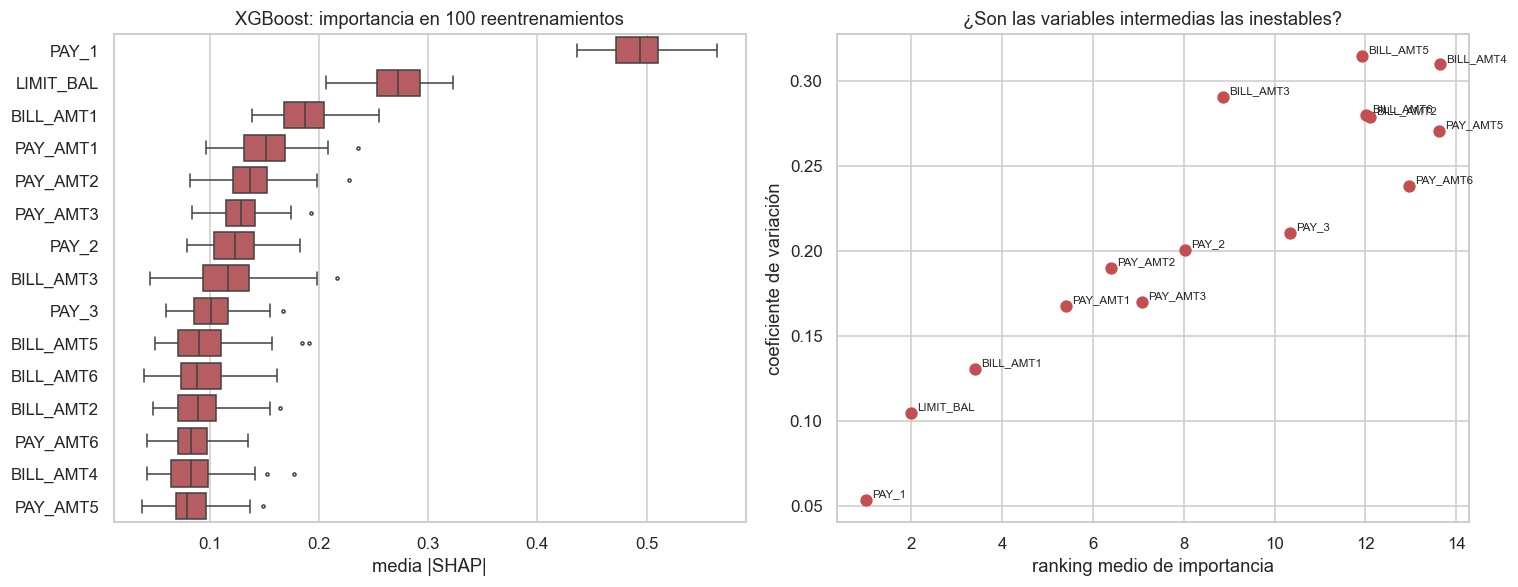

In [36]:
orden = est_xgb.index[:15]
datos_box = pd.DataFrame(rep["xgb"]["global"], columns=FEATURES)[orden]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=datos_box, orient="h", ax=axes[0], color=PALETA["xgb"], fliersize=2)
axes[0].set(xlabel="media |SHAP|", title=f"XGBoost: importancia en {N_REPEATS} reentrenamientos")

sub = est_xgb.head(15)
axes[1].scatter(sub["rank_medio"], sub["CV"], s=50, color=PALETA["xgb"])
for var, r in sub.iterrows():
    axes[1].annotate(var, (r["rank_medio"], r["CV"]), fontsize=7.5, xytext=(4, 2), textcoords="offset points")
axes[1].set(xlabel="ranking medio de importancia", ylabel="coeficiente de variación",
            title="¿Son las variables intermedias las inestables?")
plt.tight_layout()
guardar_fig("10_estabilidad_global")

La lectura de la figura de la derecha es la réplica directa de la hipótesis de Lin y Wang:
si el CV crece hacia el centro del ranking y es bajo en los extremos, se reproduce su
resultado. La correlación entre ranking medio y CV se reporta a continuación.

In [37]:
r_cv = stats.spearmanr(est_xgb["rank_medio"], est_xgb["CV"], nan_policy="omit")
print(f"Spearman(ranking medio, CV) en XGBoost: rho = {r_cv.statistic:.3f}")

# El CV se dispara donde la importancia media es casi nula, así que se repite en el top-10, que
# es donde la comparación entre modelos tiene sentido (Chen et al. y Ballegeer et al. usan SRA a
# profundidad 10 por el mismo motivo).
top10_xgb = est_xgb.head(10).index
top10_lr = est_lr.head(10).index
comp_estab = pd.DataFrame({
    "XGBoost (TreeSHAP)": [
        W_xgb, kendall_w(pd.DataFrame(rep["xgb"]["global"], columns=FEATURES)[top10_xgb].values),
        est_xgb["CV"].median(), est_xgb.loc[top10_xgb, "CV"].median(),
        (est_xgb[f"frec_top{TOP_K}"].between(0.05, 0.95)).sum()],
    "Logística (LinearSHAP)": [
        W_lr, kendall_w(pd.DataFrame(rep["lr"]["global"], columns=FEATURES)[top10_lr].values),
        est_lr["CV"].median(), est_lr.loc[top10_lr, "CV"].median(),
        (est_lr[f"frec_top{TOP_K}"].between(0.05, 0.95)).sum()],
}, index=["W de Kendall (todas)", "W de Kendall (top-10)", "CV mediano (todas)",
          "CV mediano (top-10)", f"nº variables que entran y salen del top-{TOP_K}"]).T.round(4)
guardar_tabla(comp_estab, "comparativa_estabilidad_global")
comp_estab

Spearman(ranking medio, CV) en XGBoost: rho = 0.746


,W de Kendall (todas),W de Kendall (top-10),CV mediano (todas),CV mediano (top-10),nº variables que entran y salen del top-5
XGBoost (TreeSHAP),0.8584,0.7379,0.2347,0.1799,9.0
Logística (LinearSHAP),0.7009,0.4999,0.6096,0.3297,9.0


#### SRA (*sequential rank agreement*)

El W de Kendall resume el acuerdo entre las repeticiones con un solo número y sobre las 26
variables a la vez. Chen et al. (2024) y Ballegeer et al. (2025) usan en su lugar el **SRA** de
Ekstrøm et al. (2019), que responde a una pregunta más útil aquí: *a profundidad d, ¿cuánto se
mueven de puesto las variables que alguna repetición coloca entre las d primeras?*

Formalmente, para cada profundidad `d` se toma el conjunto de variables que entran en el top-`d`
de al menos una repetición y se promedia la varianza de sus puestos entre repeticiones; el SRA es
la raíz de esa media, de modo que se lee **en puestos**. Cero es acuerdo perfecto. La escala
depende del número de variables, así que se acompaña de la referencia que darían listas
aleatorias: con 26 variables, unos 7,5 puestos.

SRA a las profundidades de interes (en puestos; 0 = acuerdo perfecto):
             XGBoost (TreeSHAP)  Logistica (LinearSHAP)  listas aleatorias
profundidad                                                               
1                         0.000                   0.000              7.515
3                         2.757                   4.964              7.515
5                         3.055                   4.642              7.515
10                        3.132                   4.567              7.515
26                        2.837                   4.122              7.515


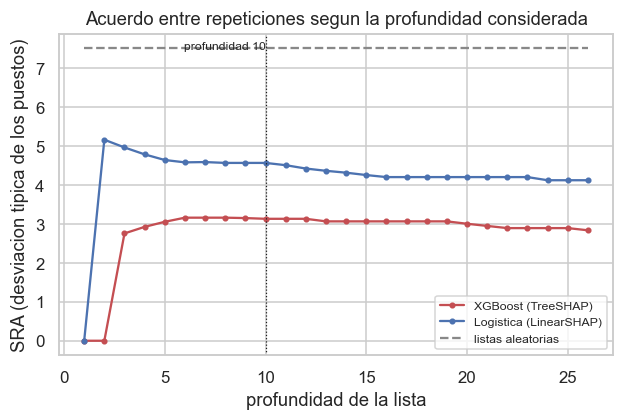

In [38]:
def sra(G: np.ndarray, profundidad: int) -> float:
    """Sequential rank agreement a una profundidad dada (Ekstrom et al., 2019).

    Cada fila de G es una repeticion y cada columna una variable, con su importancia. Se pasa a
    puestos (1 = mas importante), se toman las variables que entran en el top-`profundidad` de
    alguna repeticion y se devuelve la raiz de la varianza media de sus puestos. Se mide en
    puestos: 0 es acuerdo perfecto y valores altos, desacuerdo.
    """
    rangos = np.apply_along_axis(lambda v: stats.rankdata(-v), 1, G)
    en_top = (rangos <= profundidad).any(axis=0)
    if not en_top.any():
        return np.nan
    return float(np.sqrt(rangos[:, en_top].var(axis=0, ddof=1).mean()))


# Referencia de escala: que SRA darian listas sin ninguna relacion entre si
rs = np.random.default_rng(SEED)
G_azar = np.stack([rs.permutation(len(FEATURES)) for _ in range(N_REPEATS)]).astype(float)

PROFUNDIDADES = list(range(1, len(FEATURES) + 1))
sra_curva = pd.DataFrame({
    "XGBoost (TreeSHAP)": [sra(rep["xgb"]["global"], d) for d in PROFUNDIDADES],
    "Logistica (LinearSHAP)": [sra(rep["lr"]["global"], d) for d in PROFUNDIDADES],
    "listas aleatorias": [sra(G_azar, d) for d in PROFUNDIDADES],
}, index=PROFUNDIDADES)
sra_curva.index.name = "profundidad"

print("SRA a las profundidades de interes (en puestos; 0 = acuerdo perfecto):")
print(sra_curva.loc[[1, 3, 5, 10, len(FEATURES)]].round(3).to_string())
guardar_tabla(sra_curva.round(4), "sra_profundidad")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
sra_curva.plot(ax=ax, color=[PALETA["xgb"], PALETA["lr"], "#888888"],
               style=["-o", "-o", "--"], ms=3)
ax.axvline(10, color="k", lw=0.8, ls=":")
ax.annotate("profundidad 10", (10, ax.get_ylim()[1] * 0.95), fontsize=8, ha="right")
ax.set(xlabel="profundidad de la lista", ylabel="SRA (desviacion tipica de los puestos)",
       title="Acuerdo entre repeticiones segun la profundidad considerada")
ax.legend(fontsize=8)
guardar_fig("10c_sra")

La lectura del SRA complementa la del W y, sobre todo, la del coeficiente de variación. El CV
mediano de la logística (0,61 frente a 0,23) exagera la diferencia entre modelos, porque se
dispara en las variables cuya importancia media es casi nula: `BILL_AMT4` tiene un coeficiente de
−0,008, así que su importancia oscila alrededor de un valor prácticamente cero y el CV se va a
cualquier parte sin que eso signifique que el ranking sea inestable donde importa. El SRA a
profundidad 10 no tiene ese problema: solo mira las variables que alguna repetición considera
relevantes, y las mide en puestos, una unidad interpretable.

¿Son suficientes `N_REPEATS` repeticiones? Recalcular el W sobre los primeros 5, 6, ... R
reentrenamientos no sirve como comprobación: dos puntos consecutivos comparten casi todos los
datos, así que la curva se aplana siempre, tenga o no suficientes repeticiones. Se usa en su
lugar una partición en dos mitades independientes, más un bootstrap sobre las repeticiones para
dar un intervalo al W. Si las dos mitades coinciden y el intervalo es estrecho, el número de
repeticiones basta.

Comprobación con 100 repeticiones:
           W (todas)  W (mitad 1)  W (mitad 2)  |diferencia|  IC 95 % inferior  IC 95 % superior
modelo                                                                                          
XGBoost       0.8584       0.8589       0.8626        0.0037            0.8514            0.8678
Logística     0.7009       0.6896       0.7195        0.0299            0.6848            0.7239


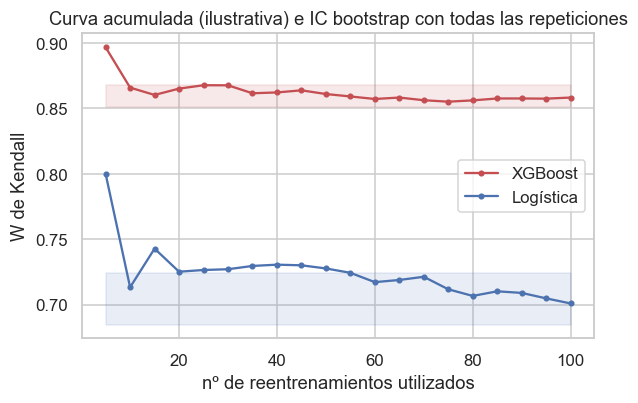

In [39]:
def w_por_mitades(G: np.ndarray, semilla: int = SEED) -> tuple[float, float]:
    """W de Kendall en dos mitades disjuntas de las repeticiones."""
    orden = np.random.default_rng(semilla).permutation(len(G))
    a, b = np.array_split(orden, 2)
    return kendall_w(G[a]), kendall_w(G[b])


def w_bootstrap(G: np.ndarray, n_boot: int = 500, semilla: int = SEED) -> tuple[float, float]:
    """Intervalo del 95 % para el W remuestreando las repeticiones."""
    rs = np.random.default_rng(semilla)
    vals = [kendall_w(G[rs.choice(len(G), len(G), replace=True)]) for _ in range(n_boot)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


filas = []
for k, nombre in [("xgb", "XGBoost"), ("lr", "Logística")]:
    G = rep[k]["global"]
    w1, w2 = w_por_mitades(G)
    lo, hi = w_bootstrap(G)
    filas.append({"modelo": nombre, "W (todas)": kendall_w(G), "W (mitad 1)": w1,
                  "W (mitad 2)": w2, "|diferencia|": abs(w1 - w2),
                  "IC 95 % inferior": lo, "IC 95 % superior": hi})
convergencia = pd.DataFrame(filas).set_index("modelo").round(4)
print(f"Comprobación con {N_REPEATS} repeticiones:")
print(convergencia.to_string())
guardar_tabla(convergencia, "convergencia_kendall_W")

# La curva acumulada se mantiene solo como ilustración de por qué no sirve como prueba
Rs = list(range(5, N_REPEATS + 1, max(1, N_REPEATS // 20)))
curva = pd.DataFrame(
    {"XGBoost": [kendall_w(rep["xgb"]["global"][:r]) for r in Rs],
     "Logística": [kendall_w(rep["lr"]["global"][:r]) for r in Rs]}, index=Rs)

fig, ax = plt.subplots(figsize=(6, 3.6))
curva.plot(ax=ax, color=[PALETA["xgb"], PALETA["lr"]], marker="o", ms=3)
for k, nombre, color in [("xgb", "XGBoost", PALETA["xgb"]), ("lr", "Logística", PALETA["lr"])]:
    lo, hi = convergencia.loc[nombre, "IC 95 % inferior"], convergencia.loc[nombre, "IC 95 % superior"]
    ax.fill_between([Rs[0], Rs[-1]], lo, hi, color=color, alpha=0.12)
ax.set(xlabel="nº de reentrenamientos utilizados", ylabel="W de Kendall",
       title="Curva acumulada (ilustrativa) e IC bootstrap con todas las repeticiones")
guardar_fig("10b_convergencia_W")

#### Robustez a la profundidad del modelo

La profundidad del árbol no es un detalle de *tuning* en este trabajo: cuanto más profundo es el
modelo, más interacciones puede representar y, en principio, más margen hay para que dos
reentrenamientos repartan el mismo efecto entre variables distintas. Si la conclusión del
análisis 2 dependiese de haber fijado `max_depth = 4`, no sería una conclusión sobre SHAP sino
sobre un hiperparámetro. Se repite el experimento con `max_depth ∈ {3, 4, 6}`, con menos
repeticiones para que el coste sea razonable, y se comprueba que el orden de magnitud del W y del
SRA se mantiene.

In [40]:
N_ROBUSTEZ = 25          # menos repeticiones que el experimento principal: solo interesa el orden de magnitud
PROFUNDIDADES_ROB = [3, 4, 6]


def estabilidad_con_profundidad(profundidad: int, n_repeats: int = N_ROBUSTEZ) -> np.ndarray:
    """Matriz (repeticiones x variables) de importancias globales para una profundidad dada."""
    params = dict(XGB_PARAMS)
    params["max_depth"] = profundidad
    n_boot = int(BOOTSTRAP_FRAC * len(X_tr))
    G = []
    for r in range(n_repeats):
        rs = np.random.default_rng(SEED + r)
        sel = rs.choice(len(X_tr), size=n_boot, replace=True)
        m = xgb.XGBClassifier(random_state=SEED + r, **params).fit(X_tr.iloc[sel], y_tr.iloc[sel])
        G.append(np.abs(shap_xgb(m, X_expl, X_bg)).mean(axis=0))
    return np.stack(G)


t0 = time.time()
filas = []
with sin_barra_de_progreso():
    for prof in PROFUNDIDADES_ROB:
        G = estabilidad_con_profundidad(prof)
        _, est = resumen_estabilidad_global(G)
        m = xgb.XGBClassifier(random_state=SEED, **{**XGB_PARAMS, "max_depth": prof}).fit(X_tr, y_tr)
        filas.append({
            "max_depth": prof,
            "ROC-AUC": roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]),
            "W de Kendall": kendall_w(G),
            "W (top-10)": kendall_w(pd.DataFrame(G, columns=FEATURES)[est.head(10).index].values),
            "SRA (prof. 10)": sra(G, 10),
            "variable dominante": est.index[0],
        })
        print(f"  max_depth = {prof} listo ({time.time() - t0:.0f} s)")

robustez = pd.DataFrame(filas).set_index("max_depth").round(4)
print()
print(f"Robustez a la profundidad ({N_ROBUSTEZ} reentrenamientos por profundidad):")
print(robustez.to_string())
guardar_tabla(robustez, "robustez_profundidad")

  max_depth = 3 listo (59 s)


  max_depth = 4 listo (141 s)


  max_depth = 6 listo (296 s)

Robustez a la profundidad (25 reentrenamientos por profundidad):
           ROC-AUC  W de Kendall  W (top-10)  SRA (prof. 10) variable dominante
max_depth                                                                      
3           0.7790        0.8447      0.7270          3.3144              PAY_1
4           0.7789        0.8678      0.7606          3.0429              PAY_1
6           0.7726        0.8970      0.7638          2.7770              PAY_1


,ROC-AUC,W de Kendall,W (top-10),SRA (prof. 10),variable dominante
max_depth,,,,,
3,0.7790,0.8447,0.7270,3.3144,PAY_1
4,0.7789,0.8678,0.7606,3.0429,PAY_1
6,0.7726,0.8970,0.7638,2.7770,PAY_1


### 8.2 Estabilidad local

Para cada cliente explicado se comparan sus `N_REPEATS` vectores de atribución entre sí.
Tres medidas complementarias:

- **similitud del coseno media por pares**: ¿apuntan las explicaciones en la misma dirección?
- **Jaccard del top-3**: ¿son los mismos los tres motivos que se le darían al cliente?
- **frecuencia del motivo principal**: ¿con qué frecuencia sale la variable más repetida
  como primera razón? (1.0 = siempre la misma).

In [41]:
def estabilidad_local(L: np.ndarray, k: int = 3) -> pd.DataFrame:
    """L: (R, N, F). Devuelve una fila por cliente."""
    R, N, F = L.shape
    iu = np.triu_indices(R, 1)
    cos_m, jac_m, top1_m = np.empty(N), np.empty(N), np.empty(N)
    for i in range(N):
        M = L[:, i, :]
        nrm = np.linalg.norm(M, axis=1, keepdims=True)
        Z = M / np.where(nrm == 0, 1e-12, nrm)
        cos_m[i] = (Z @ Z.T)[iu].mean()

        tops = [set(np.argsort(-np.abs(M[r]))[:k]) for r in range(R)]
        jac_m[i] = np.mean([len(tops[a] & tops[b]) / len(tops[a] | tops[b]) for a, b in zip(*iu)])

        primeros = np.argmax(np.abs(M), axis=1)
        top1_m[i] = np.bincount(primeros).max() / R
    return pd.DataFrame({"cos_medio": cos_m, "jaccard_top3": jac_m, "frec_motivo_principal": top1_m},
                        index=X_expl.index)


loc_xgb = estabilidad_local(rep["xgb"]["local"])
loc_lr = estabilidad_local(rep["lr"]["local"])

resumen_local = pd.DataFrame({
    "XGBoost (TreeSHAP)": loc_xgb.mean(),
    "Logística (LinearSHAP)": loc_lr.mean(),
}).T.round(4)
guardar_tabla(resumen_local, "estabilidad_local_resumen")
resumen_local

,cos_medio,jaccard_top3,frec_motivo_principal
XGBoost (TreeSHAP),0.8511,0.5066,0.7317
Logística (LinearSHAP),0.8397,0.5366,0.8716


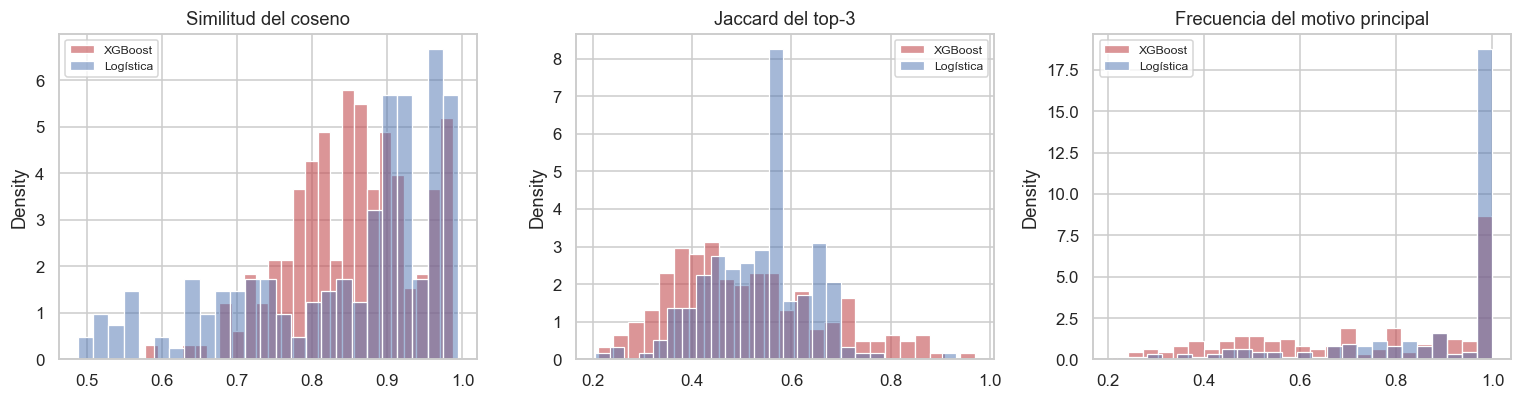

Clientes con la explicación menos estable (XGBoost):
       cos_medio  jaccard_top3  frec_motivo_principal
13732      0.578         0.281                   0.28
29491      0.631         0.285                   0.34
2719       0.659         0.259                   0.30
23038      0.676         0.373                   0.37
7146       0.682         0.302                   0.31


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for col, ax, titulo in zip(
    ["cos_medio", "jaccard_top3", "frec_motivo_principal"], axes,
    ["Similitud del coseno", "Jaccard del top-3", "Frecuencia del motivo principal"]
):
    sns.histplot(loc_xgb[col], bins=25, ax=ax, color=PALETA["xgb"], label="XGBoost", stat="density", alpha=0.6)
    sns.histplot(loc_lr[col], bins=25, ax=ax, color=PALETA["lr"], label="Logística", stat="density", alpha=0.5)
    ax.set(title=titulo, xlabel="")
    ax.legend(fontsize=8)
plt.tight_layout()
guardar_fig("11_estabilidad_local")

peor = loc_xgb.sort_values("cos_medio").head(5)
print("Clientes con la explicación menos estable (XGBoost):")
print(peor.round(3).to_string())

### 8.3 ¿Qué clientes reciben explicaciones inestables?

La hipótesis de partida era que los clientes cercanos a la frontera de decisión serían los más
inestables, lo que implicaría correlación **positiva** entre `|p - 0,5|` y la estabilidad. El
resultado sale con el signo contrario, así que hay que mirar por qué antes de darle
interpretación: `|p - 0,5|` está dominado por los clientes de probabilidad baja, cuyos vectores
SHAP tienen norma pequeña y por tanto dirección más ruidosa, que es justo lo que penaliza el
coseno. Para distinguir un efecto real de un artefacto de la métrica se mide también con una
distancia no normalizada.

Correlación de Spearman (descriptiva, sin p-valor: las observaciones no son independientes)
  |p - 0,5| vs coseno medio                      rho = -0.467
  p vs coseno medio                              rho = +0.586
  norma del vector SHAP vs coseno medio          rho = +0.645
  |p - 0,5| vs distancia media (sin normalizar)  rho = +0.108
  p vs distancia media (sin normalizar)          rho = -0.024


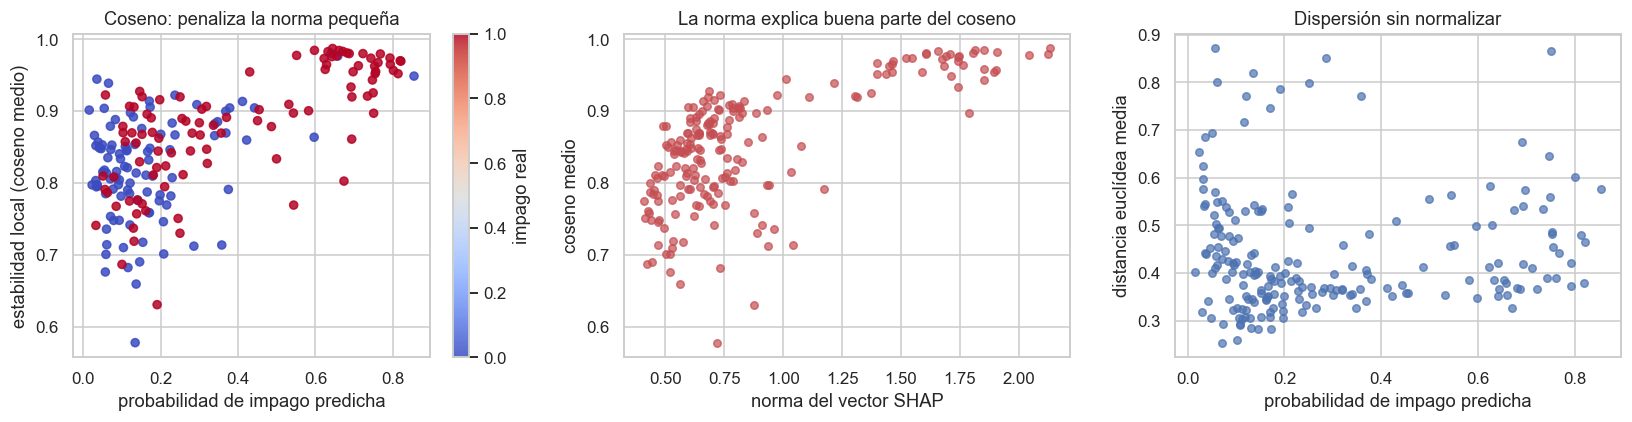

,cos_medio,jaccard_top3,frec_motivo_principal,p_impago,y_real,norma_shap,dist_media
26490,0.8853,0.6430,0.78,0.3473,0,0.6036,0.3276
15423,0.9090,0.8220,0.92,0.2935,0,0.7687,0.3688
28077,0.8108,0.3355,0.95,0.1619,0,0.4557,0.3429
1149,0.8597,0.4766,0.89,0.4222,0,0.5624,0.3521
2621,0.8826,0.5235,0.44,0.3405,0,0.6836,0.3558
...,...,...,...,...,...,...,...
16689,0.9695,0.4363,1.00,0.8211,1,1.7441,0.4651
29491,0.6306,0.2853,0.34,0.1908,1,0.8773,0.7852
12705,0.9731,0.5713,1.00,0.6225,1,1.6763,0.4118
17133,0.9809,0.8618,1.00,0.6820,1,1.8040,0.3680


In [43]:
# Dispersión no normalizada: distancia euclídea media entre las repeticiones de cada cliente
L = rep["xgb"]["local"]                       # (R, N, F)
iu = np.triu_indices(L.shape[0], 1)
dist_media = np.array([
    np.linalg.norm(L[iu[0], i, :] - L[iu[1], i, :], axis=1).mean() for i in range(L.shape[1])
])

p_expl = modelo_xgb.predict_proba(X_expl)[:, 1]
norma_shap = np.linalg.norm(sv_xgb, axis=1)
df_loc = loc_xgb.assign(p_impago=p_expl, y_real=y_expl.values,
                        norma_shap=norma_shap, dist_media=dist_media)

pares_corr = [
    ("|p - 0,5| vs coseno medio", np.abs(df_loc["p_impago"] - 0.5), df_loc["cos_medio"]),
    ("p vs coseno medio", df_loc["p_impago"], df_loc["cos_medio"]),
    ("norma del vector SHAP vs coseno medio", df_loc["norma_shap"], df_loc["cos_medio"]),
    ("|p - 0,5| vs distancia media (sin normalizar)", np.abs(df_loc["p_impago"] - 0.5), df_loc["dist_media"]),
    ("p vs distancia media (sin normalizar)", df_loc["p_impago"], df_loc["dist_media"]),
]
print("Correlación de Spearman (descriptiva, sin p-valor: las observaciones no son independientes)")
for nombre, a, b in pares_corr:
    print(f"  {nombre:<46} rho = {stats.spearmanr(a, b).statistic:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc = axes[0].scatter(df_loc["p_impago"], df_loc["cos_medio"], c=df_loc["y_real"],
                     cmap="coolwarm", s=28, alpha=0.85)
axes[0].set(xlabel="probabilidad de impago predicha", ylabel="estabilidad local (coseno medio)",
            title="Coseno: penaliza la norma pequeña")
plt.colorbar(sc, ax=axes[0], label="impago real")
axes[1].scatter(df_loc["norma_shap"], df_loc["cos_medio"], s=24, alpha=0.7, color=PALETA["xgb"])
axes[1].set(xlabel="norma del vector SHAP", ylabel="coseno medio",
            title="La norma explica buena parte del coseno")
axes[2].scatter(df_loc["p_impago"], df_loc["dist_media"], s=24, alpha=0.7, color=PALETA["lr"])
axes[2].set(xlabel="probabilidad de impago predicha", ylabel="distancia euclídea media",
            title="Dispersión sin normalizar")
plt.tight_layout()
guardar_fig("12_estabilidad_vs_prediccion")

guardar_tabla(df_loc.round(4), "estabilidad_local_por_cliente")

Las dos medidas dicen cosas distintas, y esa es la conclusión del apartado. El coseno sube con la
probabilidad predicha porque los clientes de riesgo alto tienen atribuciones grandes y de
dirección bien definida; la distancia sin normalizar se comporta al revés, porque esas mismas
atribuciones grandes tienen también más margen absoluto de variación. La hipótesis inicial, que
la inestabilidad se concentraría en la frontera de decisión, **no se sostiene con ninguna de las
dos**: lo que la métrica del coseno estaba captando era sobre todo la norma del vector, no la
cercanía a la frontera. Conviene reportar las dos medidas en la memoria y no una sola.

<a id="s9"></a>
## 9. Análisis 3 — Estabilidad ante el conjunto de referencia

García-Céspedes et al. (2025) muestran, con datos privados de BBVA, que SHAP **no es
invariante a la cartera**: la explicación de un mismo cliente cambia según la
distribución del conjunto de referencia con el que se calcula, aunque ni el cliente ni el
modelo cambien. Aquí se mide esa dimensión sobre un dataset público, que es lo que no se
ha hecho.

El modelo y los clientes son **exactamente los mismos** en todas las variantes; lo único
que cambia es el *background*. Toda diferencia observada es atribuible a esa elección.

Variantes:

| Variante | Qué representa |
|---|---|
| aleatorio n=50 / 200 / 500 | efecto del **tamaño** |
| solo no impago / solo impago / 50-50 | efecto de la **composición** (tasa de impago de la cartera) |
| límite alto / límite bajo | efecto de un **segmento comercial** distinto |
| límite alto / bajo con tasa igualada | el mismo segmento, pero con la tasa de impago de la referencia |
| path-dependent | variante algorítmica que **no usa background** |

Las dos variantes de segmento «crudas» no son limpias: el cuartil superior de `LIMIT_BAL`
impaga menos que la cartera media y el inferior más, así que cambian a la vez el perfil de
los clientes **y** la composición de clases, y su efecto no es separable del que ya miden las
variantes de composición. Se mantienen porque son las que se darían en la práctica —una
entidad que explica su cartera *premium* usa la cartera *premium* como referencia, con la
tasa de impago que tenga—, pero se acompañan de una versión remuestreada dentro del mismo
segmento hasta igualar la tasa de la referencia. La comparación entre las dos versiones es lo
que separa «es otro tipo de cliente» de «impaga menos».

In [44]:
def muestra_con_tasa(pool: pd.Index, tasa: float, n: int, semilla: int) -> pd.DataFrame:
    """Muestra de `n` filas del subconjunto `pool` con la tasa de impago indicada."""
    y_pool = y_tr.loc[pool]
    n_si = min(int(round(n * tasa)), int((y_pool == 1).sum()))
    si = y_pool[y_pool == 1].sample(n_si, random_state=semilla).index
    no = y_pool[y_pool == 0].sample(n - n_si, random_state=semilla).index
    return X_tr.loc[si.append(no)]


def construir_backgrounds() -> dict[str, pd.DataFrame]:
    tr_no = X_tr[y_tr == 0]
    tr_si = X_tr[y_tr == 1]
    n = BACKGROUND_SIZE
    lim = X_tr_raw.loc[X_tr.index, "LIMIT_BAL"]
    alto = lim[lim >= lim.quantile(0.75)].index
    bajo = lim[lim <= lim.quantile(0.25)].index
    tasa_ref = float(y_tr.loc[X_bg.index].mean())
    bgs = {
        "aleatorio n=50": X_tr.sample(50, random_state=SEED),
        "aleatorio n=200 (referencia)": X_bg,
        "aleatorio n=500": X_tr.sample(500, random_state=SEED),
        "solo no impago": tr_no.sample(n, random_state=SEED),
        "solo impago": tr_si.sample(min(n, len(tr_si)), random_state=SEED),
        "50 % impago": pd.concat([tr_no.sample(n // 2, random_state=SEED),
                                  tr_si.sample(n // 2, random_state=SEED)]),
        "límite alto (P75+)": X_tr.loc[alto].sample(n, random_state=SEED),
        "límite bajo (P25-)": X_tr.loc[bajo].sample(n, random_state=SEED),
        # Las dos anteriores cambian a la vez el segmento y la tasa de impago (el limite alto
        # impaga menos que la cartera media y el bajo mas), asi que su efecto no seria
        # separable del que ya miden las variantes de composicion. Estas dos remuestrean
        # dentro del mismo segmento hasta igualar la tasa de la referencia, de modo que lo
        # unico que cambia respecto a ella es el perfil de los clientes.
        "límite alto (tasa igualada)": muestra_con_tasa(alto, tasa_ref, n, SEED),
        "límite bajo (tasa igualada)": muestra_con_tasa(bajo, tasa_ref, n, SEED),
        "otra muestra aleatoria n=200": X_tr.sample(n, random_state=SEED + 999),
    }
    return bgs


backgrounds = construir_backgrounds()
REFERENCIA = "aleatorio n=200 (referencia)"

sv_bg: dict[str, np.ndarray] = {}
base_bg: dict[str, float] = {}
t0 = time.time()
with sin_barra_de_progreso():
    for nombre, bg in backgrounds.items():
        expl = explicador_xgb(modelo_xgb, bg)
        sv_bg[nombre] = np.asarray(expl.shap_values(X_expl))
        base_bg[nombre] = float(np.ravel(expl.expected_value)[0])
        print(f"  {nombre:<32} n = {len(bg):>3} | tasa impago bg = "
              f"{y_tr.loc[bg.index].mean():.3f} | base = {base_bg[nombre]:+.4f}")

# variante sin background
expl_pd = explicador_xgb(modelo_xgb, perturbation="tree_path_dependent")
sv_bg["path-dependent (sin bg)"] = np.asarray(expl_pd.shap_values(X_expl))
base_bg["path-dependent (sin bg)"] = float(np.ravel(expl_pd.expected_value)[0])
print(f"  path-dependent (sin bg)          base = {base_bg['path-dependent (sin bg)']:+.4f}")
print(f"Calculado en {time.time() - t0:.0f} s")

  aleatorio n=50                   n =  50 | tasa impago bg = 0.260 | base = -1.6045


  aleatorio n=200 (referencia)     n = 200 | tasa impago bg = 0.200 | base = -1.5251


  aleatorio n=500                  n = 500 | tasa impago bg = 0.224 | base = -1.5103


  solo no impago                   n = 200 | tasa impago bg = 0.000 | base = -1.9143


  solo impago                      n = 200 | tasa impago bg = 1.000 | base = -0.4169


...

  límite alto (P75+)               n = 200 | tasa impago bg = 0.140 | base = -2.2089


  límite bajo (P25-)               n = 200 | tasa impago bg = 0.305 | base = -0.8821


  límite alto (tasa igualada)      n = 200 | tasa impago bg = 0.200 | base = -2.1276


  límite bajo (tasa igualada)      n = 200 | tasa impago bg = 0.200 | base = -1.1443


  otra muestra aleatoria n=200     n = 200 | tasa impago bg = 0.245 | base = -1.5937
  path-dependent (sin bg)          base = -1.2794
Calculado en 32 s


In [45]:
ref = sv_bg[REFERENCIA]
imp_ref = importancia_global(ref)

filas = []
for nombre, sv in sv_bg.items():
    imp = importancia_global(sv)
    rho_g = stats.spearmanr(imp_ref.values, imp.values).statistic
    sol_bg = solapamiento_topk(imp_ref, imp)
    cos_l = cos_sim(ref, sv)
    top1_ref = np.argmax(np.abs(ref), axis=1)
    top1_var = np.argmax(np.abs(sv), axis=1)
    filas.append({
        "background": nombre,
        "valor_base": base_bg[nombre],
        "Spearman_global": rho_g,
        f"coincidencias_top{TOP_K}": sol_bg["coincidencias"],
        "cos_local_medio": cos_l.mean(),
        "cos_local_p10": np.percentile(cos_l, 10),
        "cambia_motivo_principal_%": 100 * (top1_ref != top1_var).mean(),
    })

tabla_bg = pd.DataFrame(filas).set_index("background").round(4)
guardar_tabla(tabla_bg, "estabilidad_background")
tabla_bg

,valor_base,Spearman_global,coincidencias_top5,cos_local_medio,cos_local_p10,cambia_motivo_principal_%
background,,,,,,
aleatorio n=50,-1.6045,0.9685,5,0.9912,0.9829,9.0
aleatorio n=200 (referencia),-1.5251,1.0000,5,1.0000,1.0000,0.0
aleatorio n=500,-1.5103,0.9925,5,0.9989,0.9977,3.5
solo no impago,-1.9143,0.9884,5,0.9819,0.9644,14.5
solo impago,-0.4169,0.9330,3,0.8823,0.7941,49.0
50 % impago,-1.1952,0.9870,5,0.9770,0.9608,29.0
límite alto (P75+),-2.2089,0.9843,5,0.8571,0.6527,42.0
límite bajo (P25-),-0.8821,0.9521,4,0.8562,0.6659,50.0
límite alto (tasa igualada),-2.1276,0.9809,5,0.8563,0.6417,42.0


#### El desplazamiento del valor base

Antes de leer la tabla hay que descontar un efecto aritmético. Por la propiedad de eficiencia,
`sum(phi) + base = logit`, y ni el modelo ni el cliente cambian entre variantes: el logit es
exactamente el mismo. Así que si el valor base se mueve `Δ`, la suma de las atribuciones tiene
que moverse `−Δ` **obligatoriamente**, sin que ninguna variable haya cambiado de papel. Y el
rango de valores base entre variantes es amplio: de −2,21 en «límite alto (P75+)» a −0,42 en
«solo impago», casi 1,8 unidades de log-odds.

Esto importa porque la similitud del coseno es invariante a la escala pero **no a la
traslación**: parte de la caída de `cos_local_medio` es mecánica. No invalida el resultado —es
justamente el punto de García-Céspedes et al.: si el punto de referencia se mueve, la explicación
que recibe el cliente cambia aunque el modelo no—, pero obliga a separar dos afirmaciones muy
distintas: *«se movió el punto de referencia»* y *«cambió el orden relativo entre las variables»*.

Las medidas que responden a la segunda son `Spearman_global` y `coincidencias_top5`, insensibles
a cualquier desplazamiento. A ellas se añade aquí la similitud entre **perfiles normalizados**
`phi / sum|phi|`, que compara el reparto relativo del peso entre variables y no cuánto pesa el
conjunto, y el coseno recalculado después de descontar el desplazamiento forzado.

In [46]:
p_var = len(FEATURES)
d_base = {nombre: base_bg[nombre] - base_bg[REFERENCIA] for nombre in sv_bg}


def perfil(sv: np.ndarray) -> np.ndarray:
    """Atribuciones normalizadas phi / sum|phi|: como se reparte el peso, no cuanto pesa."""
    total = np.abs(sv).sum(axis=1, keepdims=True)
    return sv / np.where(total == 0, 1.0, total)


filas = []
for nombre, sv in sv_bg.items():
    delta = sv - ref
    # Comprobacion de la identidad: sum(phi_variante) - sum(phi_ref) tiene que valer -Delta base
    err_id = float(np.abs(delta.sum(axis=1) + d_base[nombre]).max())
    # Parte del movimiento que es el desplazamiento forzado, repartido por igual entre variables
    forzada = np.full_like(delta, -d_base[nombre] / p_var)
    peso_forzado = float(np.linalg.norm(forzada) / max(np.linalg.norm(delta), 1e-12))
    filas.append({
        "background": nombre,
        "delta_base": d_base[nombre],
        "error_identidad": err_id,
        "% del movimiento que es desplazamiento": 100 * peso_forzado,
        "cos_local_medio": float(cos_sim(ref, sv).mean()),
        "cos tras descontar el desplazamiento": float(cos_sim(ref, sv - forzada).mean()),
        "similitud de perfiles normalizados": float(1 - 0.5 * np.abs(perfil(ref) - perfil(sv)).sum(axis=1).mean()),
    })

tabla_base = pd.DataFrame(filas).set_index("background")
print(f"Maximo error en la identidad de eficiencia entre variantes: "
      f"{tabla_base['error_identidad'].max():.2e} (confirma que el logit no cambia)")
print()
print(tabla_base.drop(columns="error_identidad").round(4).to_string())
guardar_tabla(tabla_base.round(6), "background_desplazamiento_base")

Maximo error en la identidad de eficiencia entre variantes: 7.26e-07 (confirma que el logit no cambia)

                              delta_base  % del movimiento que es desplazamiento  cos_local_medio  cos tras descontar el desplazamiento  similitud de perfiles normalizados
background                                                                                                                                                                 
aleatorio n=50                   -0.0793                                 13.4541           0.9912                                0.9913                              0.9306
aleatorio n=200 (referencia)      0.0000                                  0.0000           1.0000                                1.0000                              1.0000
aleatorio n=500                   0.0148                                  8.2399           0.9989                                0.9989                              0.9751
solo no impago                   -0.

,delta_base,error_identidad,% del movimiento que es desplazamiento,cos_local_medio,cos tras descontar el desplazamiento,similitud de perfiles normalizados
background,,,,,,
aleatorio n=50,-0.079346,0.000000,13.454055,0.991167,0.991301,0.930618
aleatorio n=200 (referencia),0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
aleatorio n=500,0.014809,0.000000,8.239878,0.998861,0.998861,0.975050
solo no impago,-0.389185,0.000000,53.416130,0.981877,0.986740,0.911042
solo impago,1.108262,0.000000,45.181676,0.882268,0.900385,0.791353
50 % impago,0.329898,0.000000,35.658516,0.976952,0.978757,0.917005
límite alto (P75+),-0.683761,0.000000,31.917280,0.857056,0.872596,0.796826
límite bajo (P25-),0.643069,0.000000,28.712488,0.856239,0.861746,0.788494
límite alto (tasa igualada),-0.602446,0.000000,28.522802,0.856270,0.868908,0.783569


Correlacion de Spearman con |delta del valor base| (descriptiva, 10 variantes):
  cos_local_medio                            rho = -0.727
  cos tras descontar el desplazamiento       rho = -0.727
  similitud de perfiles normalizados         rho = -0.791
  Spearman_global                            rho = -0.464
  coincidencias_top5                         rho = -0.426
  cambia_motivo_principal_%                  rho = +0.774


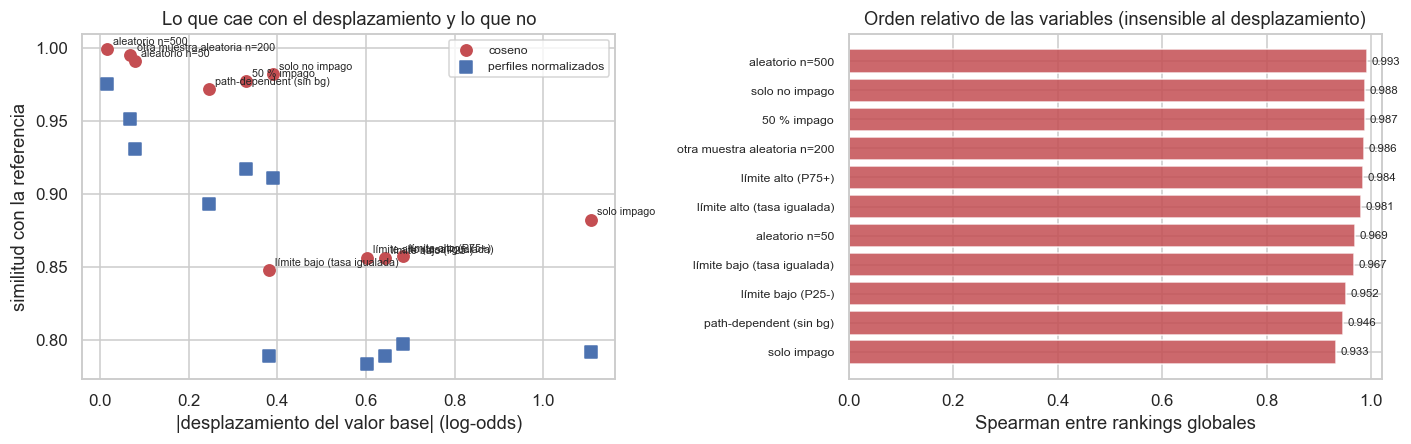

In [47]:
# Que medidas responden al desplazamiento del base y cuales al cambio de orden
otras = [n for n in sv_bg if n != REFERENCIA]
med = tabla_bg.join(tabla_base.drop(columns=["error_identidad", "cos_local_medio"])).loc[otras]
abs_delta = med["delta_base"].abs()

print("Correlacion de Spearman con |delta del valor base| (descriptiva, 10 variantes):")
for col in ["cos_local_medio", "cos tras descontar el desplazamiento",
            "similitud de perfiles normalizados", "Spearman_global",
            f"coincidencias_top{TOP_K}", "cambia_motivo_principal_%"]:
    r = stats.spearmanr(abs_delta, med[col]).statistic
    print(f"  {col:<42} rho = {r:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(abs_delta, med["cos_local_medio"], s=55, color=PALETA["xgb"], label="coseno")
axes[0].scatter(abs_delta, med["similitud de perfiles normalizados"], s=55, marker="s",
                color=PALETA["lr"], label="perfiles normalizados")
for nombre, r in med.iterrows():
    axes[0].annotate(nombre, (abs(r["delta_base"]), r["cos_local_medio"]), fontsize=7,
                     xytext=(4, 3), textcoords="offset points")
axes[0].set(xlabel="|desplazamiento del valor base| (log-odds)", ylabel="similitud con la referencia",
            title="Lo que cae con el desplazamiento y lo que no")
axes[0].legend(fontsize=8)

orden_m = med.sort_values("Spearman_global")
axes[1].barh(range(len(orden_m)), orden_m["Spearman_global"], color=PALETA["xgb"], alpha=0.85)
axes[1].set_yticks(range(len(orden_m)), orden_m.index, fontsize=8)
axes[1].set(xlim=(0, 1.02), xlabel="Spearman entre rankings globales",
            title="Orden relativo de las variables (insensible al desplazamiento)")
for k, v in enumerate(orden_m["Spearman_global"]):
    axes[1].annotate(f"{v:.3f}", (v, k), fontsize=7.5, va="center", xytext=(3, 0),
                     textcoords="offset points")
plt.tight_layout()
guardar_fig("13b_background_desplazamiento")

#### Antes de decir «cambia el motivo principal en la mitad de los casos»

`cambia_motivo_principal_%` es la medida más llamativa del apartado, y también la más fácil de
sobreinterpretar: si en un cliente la primera y la segunda atribución están prácticamente
empatadas, que se intercambien no es una explicación distinta, es ruido de desempate. La
comprobación pertinente es mirar cuánto se separaban esas dos atribuciones **en la explicación de
referencia**, comparando los clientes que cambian de motivo con los que no.

La brecha es (|phi_1| - |phi_2|) / |phi_1| en la explicacion de referencia:
                              % que cambia de motivo  brecha 1a-2a mediana (cambian)  brecha 1a-2a mediana (no cambian)  % de los que cambian con brecha < 20 %
background                                                                                                                                                     
aleatorio n=50                                   9.0                           0.077                              0.346                                  88.889
aleatorio n=500                                  3.5                           0.029                              0.320                                 100.000
solo no impago                                  14.5                           0.157                              0.359                                  58.621
solo impago                                     49.0                           0.178                              0.457     

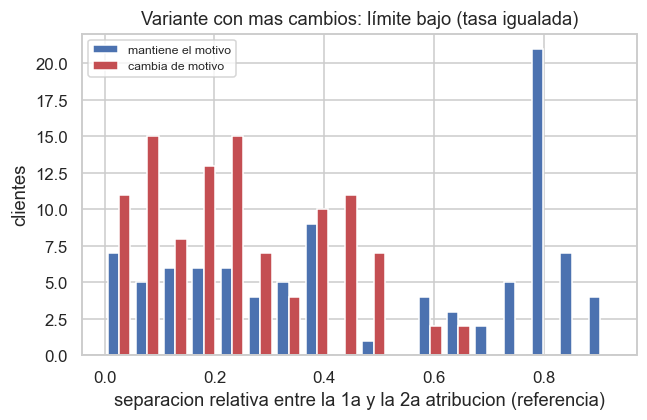

In [48]:
abs_ref = np.abs(ref)
ordenadas = np.sort(abs_ref, axis=1)[:, ::-1]
brecha = (ordenadas[:, 0] - ordenadas[:, 1]) / np.where(ordenadas[:, 0] == 0, np.nan, ordenadas[:, 0])
top1_ref = np.argmax(abs_ref, axis=1)

filas = []
for nombre in otras:
    cambia = np.argmax(np.abs(sv_bg[nombre]), axis=1) != top1_ref
    if cambia.sum() == 0:
        continue
    filas.append({
        "background": nombre,
        "% que cambia de motivo": 100 * cambia.mean(),
        "brecha 1a-2a mediana (cambian)": float(np.nanmedian(brecha[cambia])),
        "brecha 1a-2a mediana (no cambian)": float(np.nanmedian(brecha[~cambia])),
        "% de los que cambian con brecha < 20 %": 100 * float(np.nanmean(brecha[cambia] < 0.20)),
    })
brechas = pd.DataFrame(filas).set_index("background").round(3)
print("La brecha es (|phi_1| - |phi_2|) / |phi_1| en la explicacion de referencia:")
print(brechas.to_string())
guardar_tabla(brechas, "background_brecha_motivo")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
peor = brechas["% que cambia de motivo"].idxmax()
cambia_peor = np.argmax(np.abs(sv_bg[peor]), axis=1) != top1_ref
ax.hist([brecha[~cambia_peor], brecha[cambia_peor]], bins=18, stacked=False,
        color=[PALETA["lr"], PALETA["xgb"]], label=["mantiene el motivo", "cambia de motivo"])
ax.set(xlabel="separacion relativa entre la 1a y la 2a atribucion (referencia)",
       ylabel="clientes", title=f"Variante con mas cambios: {peor}")
ax.legend(fontsize=8)
guardar_fig("13c_brecha_motivo")

Lectura del apartado, en este orden:

1. **El ranking global es robusto.** `Spearman_global` y `coincidencias_top5` no dependen del
   valor base, y son las que responden a la pregunta «¿cambian de papel las variables?».
2. **La explicación individual lo es menos.** El coseno local baja, pero antes de atribuirlo al
   background hay que descontar el desplazamiento del valor base, que lo hace bajar por
   aritmética; la columna «cos tras descontar el desplazamiento» y la similitud entre perfiles
   normalizados dan la parte que no es mecánica.
3. **El cambio de motivo principal es real, pero hay que decir en qué casos.** Se concentra en
   los clientes cuya primera y segunda atribución estaban casi empatadas en la explicación de
   referencia; en los que tenían un motivo claramente dominante, el motivo se mantiene.
4. **Segmento y composición son cosas distintas.** Comparando «límite alto (P75+)» con «límite
   alto (tasa igualada)» se ve cuánto del efecto venía de que ese segmento impaga menos y cuánto
   de que sus clientes son distintos.

Ese matiz —global estable, local no— es exactamente lo que se pierde cuando la estabilidad se
evalúa solo con una medida agregada, y es el hueco que el trabajo pretende cubrir.

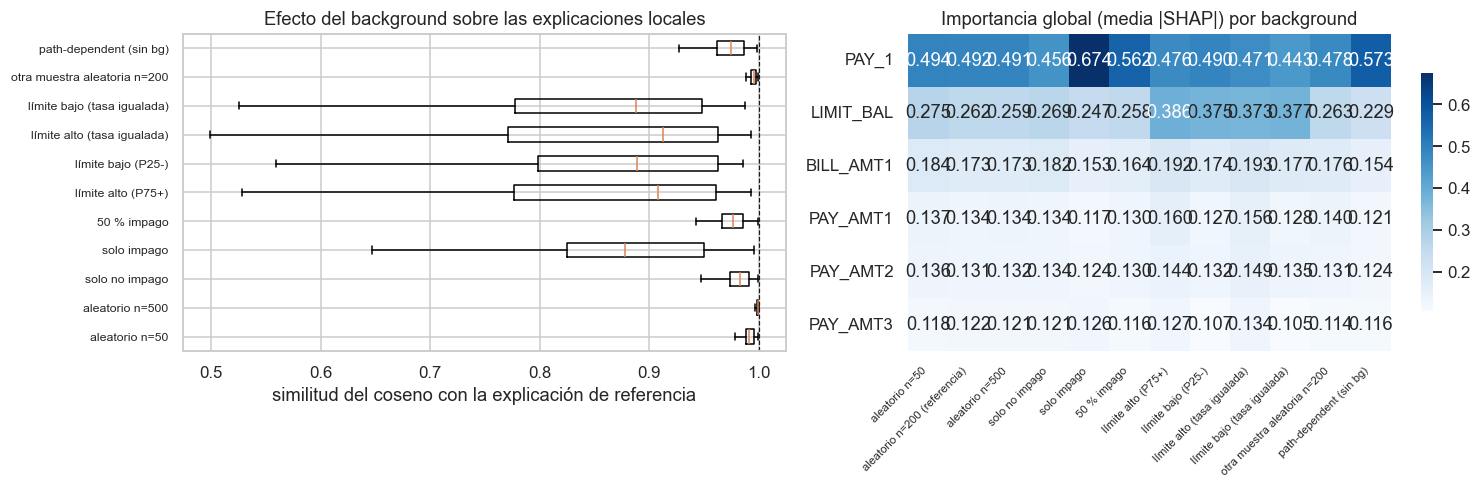

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

orden_bg = [n for n in sv_bg if n != REFERENCIA]
vals = [cos_sim(ref, sv_bg[n]) for n in orden_bg]
axes[0].boxplot(vals, vert=False, showfliers=False)
axes[0].set_yticks(range(1, len(orden_bg) + 1), orden_bg, fontsize=8)
axes[0].axvline(1.0, ls="--", c="k", lw=0.8)
axes[0].set(xlabel="similitud del coseno con la explicación de referencia",
            title="Efecto del background sobre las explicaciones locales")

top6 = imp_ref.nlargest(6).index
mat = pd.DataFrame({n: importancia_global(sv_bg[n])[top6] for n in sv_bg})
sns.heatmap(mat, annot=True, fmt=".3f", cmap="Blues", ax=axes[1], cbar_kws={"shrink": 0.75})
axes[1].set(title="Importancia global (media |SHAP|) por background")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=7.5)
plt.tight_layout()
guardar_fig("13_background")

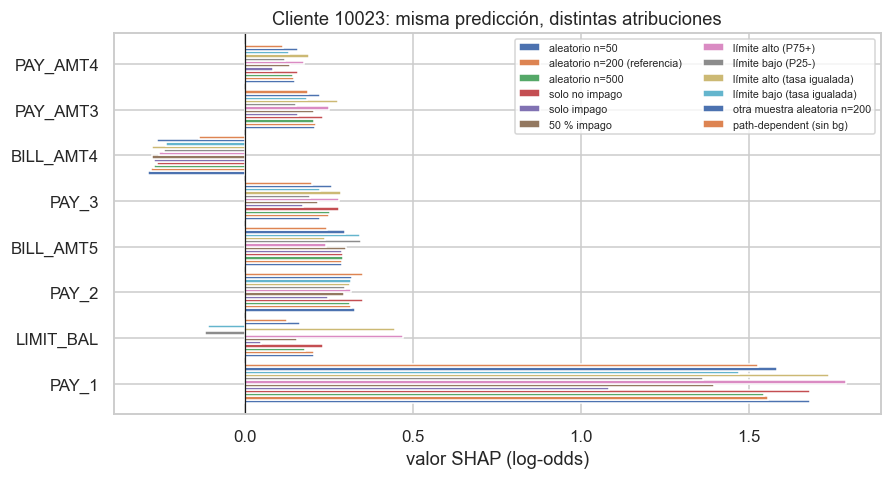

,aleatorio n=50,aleatorio n=200 (referencia),aleatorio n=500,solo no impago,solo impago,50 % impago,límite alto (P75+),límite bajo (P25-),límite alto (tasa igualada),límite bajo (tasa igualada),otra muestra aleatoria n=200,path-dependent (sin bg)
PAY_1,1.682,1.556,1.545,1.681,1.083,1.396,1.788,1.364,1.738,1.469,1.584,1.527
LIMIT_BAL,0.206,0.206,0.178,0.232,0.050,0.157,0.472,-0.119,0.448,-0.108,0.164,0.127
PAY_2,0.328,0.315,0.315,0.351,0.247,0.295,0.316,0.299,0.313,0.316,0.319,0.351
BILL_AMT5,0.290,0.289,0.293,0.292,0.290,0.300,0.242,0.347,0.240,0.344,0.299,0.243
PAY_3,0.226,0.252,0.254,0.280,0.173,0.217,0.281,0.195,0.287,0.223,0.260,0.201
BILL_AMT4,-0.286,-0.279,-0.270,-0.261,-0.269,-0.275,-0.254,-0.241,-0.274,-0.234,-0.261,-0.137
PAY_AMT3,0.208,0.213,0.207,0.233,0.158,0.205,0.250,0.154,0.278,0.187,0.224,0.188
PAY_AMT4,0.150,0.147,0.145,0.160,0.083,0.134,0.177,0.120,0.192,0.132,0.158,0.115


In [50]:
# Efecto sobre un cliente concreto: la misma persona, distinta explicación
i = i_cliente
comp_cliente = pd.DataFrame({n: sv_bg[n][i] for n in sv_bg}, index=FEATURES)
comp_cliente = comp_cliente.loc[comp_cliente.abs().max(axis=1).nlargest(8).index]

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_cliente.plot.barh(ax=ax, width=0.85)
ax.axvline(0, c="k", lw=0.8)
ax.set(xlabel="valor SHAP (log-odds)",
       title=f"Cliente {X_expl.index[i]}: misma predicción, distintas atribuciones")
ax.legend(fontsize=7, ncol=2)
guardar_fig("14_background_cliente")

guardar_tabla(comp_cliente.round(4), "background_cliente_ejemplo")
comp_cliente.round(3)

<a id="s10"></a>
## 10. Análisis 4 — Consistencia y coherencia

Dos propiedades distintas de la estabilidad ante reentrenamientos:

- **Consistencia**: clientes con perfiles casi idénticos deberían recibir explicaciones
  casi idénticas. Si no, la explicación no serviría para justificar por qué a uno se le
  deniega el crédito y a otro no.
- **Coherencia**: la dirección de los efectos debe tener sentido financiero (más retrasos
  de pago ⇒ más riesgo). Un modelo puede ser estable y aun así incoherente.

In [51]:
N_CONSIST = 1000
X_cons = X_te.sample(n=min(N_CONSIST, len(X_te)), random_state=SEED)
with sin_barra_de_progreso():
    sv_cons = shap_xgb(modelo_xgb, X_cons, X_bg)
p_cons = modelo_xgb.predict_proba(X_cons)[:, 1]

# La distancia euclidea sobre la matriz de diseno mezcla dos escalas: las numericas estan
# estandarizadas (una unidad = una desviacion tipica) y las dummies valen 0 o 1, asi que un
# cambio de categoria cuenta como una desviacion tipica entera. Es una eleccion, no una
# propiedad: se declara y se comprueba enseguida que el resultado no depende de ella,
# repitiendo la medida solo sobre el bloque numerico.
DUMMY_COLS = [c for c in FEATURES if c not in NUM_COLS]

nn = NearestNeighbors(n_neighbors=2).fit(X_cons.values)
dist, vecinos = nn.kneighbors(X_cons.values)
d_x = dist[:, 1]                 # distancia al vecino más próximo (excluyéndose a sí mismo)
vec = vecinos[:, 1]
d_shap = np.linalg.norm(sv_cons - sv_cons[vec], axis=1)
d_p = np.abs(p_cons - p_cons[vec])

pares = pd.DataFrame({
    "cliente": X_cons.index, "vecino": X_cons.index[vec],
    "dist_features": d_x, "dist_shap": d_shap, "dif_prob": d_p,
    "cos_shap": cos_sim(sv_cons, sv_cons[vec]),
})

rho_c = stats.spearmanr(pares["dist_features"], pares["dist_shap"])
# Sin p-valor: los pares no son independientes (un mismo cliente puede ser el vecino de varios)
print(f"Spearman(distancia entre perfiles, distancia entre explicaciones) = {rho_c.statistic:.3f}")

# La misma medida sin las dummies, para comprobar que la mezcla de escalas no decide el resultado
nn_num = NearestNeighbors(n_neighbors=2).fit(X_cons[NUM_COLS].values)
dist_num, vec_num = nn_num.kneighbors(X_cons[NUM_COLS].values)
rho_num = stats.spearmanr(dist_num[:, 1],
                          np.linalg.norm(sv_cons - sv_cons[vec_num[:, 1]], axis=1)).statistic
print(f"Lo mismo usando solo las {len(NUM_COLS)} variables numericas = {rho_num:.3f}")

umbral = np.quantile(d_x, 0.05)
cercanos = pares[pares["dist_features"] <= umbral]
# Que significa ese umbral: en esta escala, cambiar una sola dummy ya aporta una distancia de 1,
# muy por encima del umbral, asi que los pares "proximos" comparten obligatoriamente sexo,
# estudios y estado civil, y difieren como mucho lo que indica el umbral en las numericas.
iguales_cat = (X_cons[DUMMY_COLS].values == X_cons[DUMMY_COLS].values[vec]).all(axis=1)
print(f"\nPares muy próximos (5 % más cercanos, distancia <= {umbral:.3f}): {len(cercanos)}")
print(f"  el umbral equivale a {umbral:.3f} desviaciones tipicas repartidas entre las "
      f"{len(NUM_COLS)} variables numericas (una sola dummy distinta aportaria 1,000)")
print(f"  comparten las tres variables categoricas: "
      f"{100 * iguales_cat[pares['dist_features'].values <= umbral].mean():.1f} % de esos pares")
print(f"  similitud del coseno entre sus explicaciones: mediana {cercanos['cos_shap'].median():.3f}, "
      f"mínimo {cercanos['cos_shap'].min():.3f}")

Spearman(distancia entre perfiles, distancia entre explicaciones) = 0.573
Lo mismo usando solo las 20 variables numericas = 0.616

Pares muy próximos (5 % más cercanos, distancia <= 0.366): 50
  el umbral equivale a 0.366 desviaciones tipicas repartidas entre las 20 variables numericas (una sola dummy distinta aportaria 1,000)
  comparten las tres variables categoricas: 100.0 % de esos pares
  similitud del coseno entre sus explicaciones: mediana 0.947, mínimo 0.692


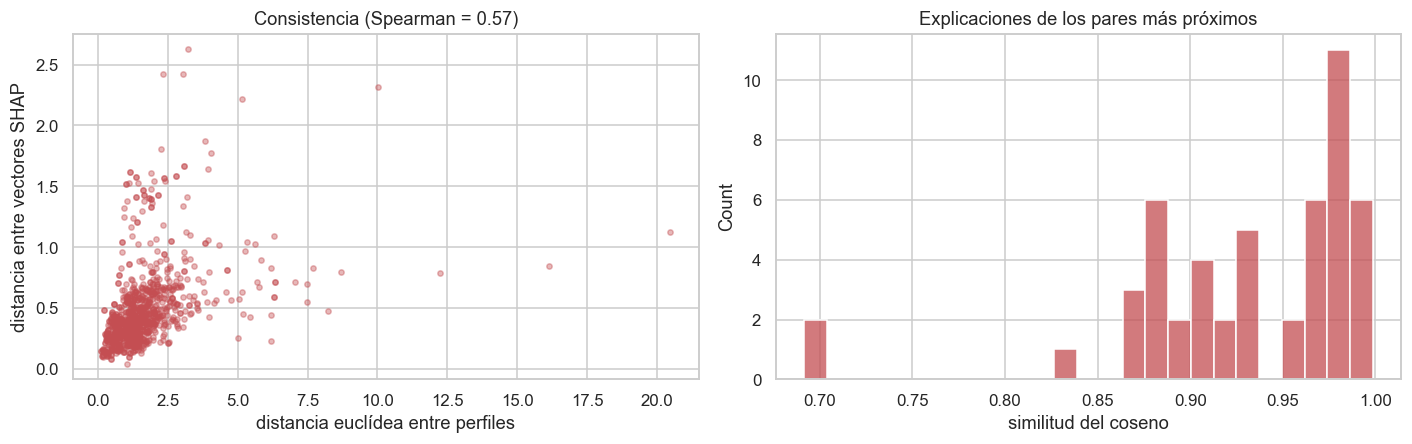

,cliente,vecino,dist_features,dist_shap,dif_prob,cos_shap
373,25424,19209,0.209,0.486,0.116,0.692
347,19209,25424,0.209,0.486,0.116,0.692
927,27633,15882,0.350,0.361,0.044,0.836
54,1450,25413,0.309,0.300,0.031,0.864
294,25413,1450,0.309,0.300,0.031,0.864


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(pares["dist_features"], pares["dist_shap"], s=12, alpha=0.4, color=PALETA["xgb"])
axes[0].set(xlabel="distancia euclídea entre perfiles", ylabel="distancia entre vectores SHAP",
            title=f"Consistencia (Spearman = {rho_c.statistic:.2f})")
sns.histplot(cercanos["cos_shap"], bins=25, ax=axes[1], color=PALETA["xgb"])
axes[1].set(xlabel="similitud del coseno", title="Explicaciones de los pares más próximos")
plt.tight_layout()
guardar_fig("15_consistencia")

peores = cercanos.sort_values("cos_shap").head(5)
guardar_tabla(pares.round(4), "consistencia_pares", index=False)
peores.round(3)

Los duplicados exactos del apartado 3 dan una comprobación de implementación que no cuesta nada:
dos clientes con **exactamente** el mismo perfil tienen que recibir atribuciones idénticas, sea
cual sea el modelo. Es el caso límite de la consistencia, y el único en el que se conoce la
respuesta correcta de antemano, así que sirve para verificar que el cálculo no arrastra ninguna
dependencia del orden de las filas ni del muestreo interno del *masker*.

In [53]:
h_te = pd.util.hash_pandas_object(X_te, index=False)
idx_rep = X_te.index[h_te.duplicated(keep=False).values]

if len(idx_rep) == 0:
    print("No hay perfiles repetidos en el conjunto de test: la comprobacion no aplica.")
else:
    with sin_barra_de_progreso():
        sv_rep = shap_xgb(modelo_xgb, X_te.loc[idx_rep], X_bg)
    marco = pd.DataFrame(sv_rep, columns=FEATURES)
    marco["_grupo"] = h_te.loc[idx_rep].values
    dispersion = marco.groupby("_grupo").agg(lambda s: s.max() - s.min())
    print(f"Perfiles repetidos en test: {len(idx_rep)} filas en {marco['_grupo'].nunique()} grupos")
    print(f"Maxima diferencia dentro de un grupo de filas identicas: {dispersion.values.max():.2e}")
    print("  ->", "OK" if dispersion.values.max() < 1e-9 else "REVISAR",
          "(filas identicas reciben atribuciones identicas)")

Perfiles repetidos en test: 8 filas en 4 grupos
Maxima diferencia dentro de un grupo de filas identicas: 0.00e+00
  -> OK (filas identicas reciben atribuciones identicas)


### 10.1 Coherencia financiera

Se contrasta el signo observado del efecto (correlación entre valor de la variable y su
atribución) con el signo esperado por criterio financiero, definido en el diccionario del
apartado 1.1.

In [54]:
sig_obs = signo_efecto(sv_cons, X_cons)
coh = pd.DataFrame({
    "corr_valor_shap": sig_obs,
    "signo_esperado": pd.Series(SIGNO_ESPERADO).reindex(FEATURES),
    "importancia": importancia_global(sv_cons),
}).dropna(subset=["signo_esperado", "corr_valor_shap"])
coh["signo_observado"] = np.sign(coh["corr_valor_shap"]).astype(int)
coh["coherente"] = np.where(
    coh["signo_esperado"] == 0, "sin expectativa",
    np.where(coh["signo_observado"] == coh["signo_esperado"], "sí", "NO"),
)

con_expectativa = coh[coh["signo_esperado"] != 0]
print(f"Variables con signo esperado: {len(con_expectativa)} | "
      f"coherentes en dirección global: {(con_expectativa['coherente'] == 'sí').sum()}")
print("Incoherentes:", list(con_expectativa.index[con_expectativa['coherente'] == 'NO']))
print("\nAviso: esta comprobación solo mira la dirección global del efecto. Una variable puede")
print("tener el signo esperado y aun así no ser monótona, como se ve enseguida con PAY_*.")

guardar_tabla(coh.sort_values("importancia", ascending=False).round(4), "coherencia_signos")
coh.sort_values("importancia", ascending=False).head(12).round(3)

Variables con signo esperado: 13 | coherentes en dirección global: 13
Incoherentes: []

Aviso: esta comprobación solo mira la dirección global del efecto. Una variable puede
tener el signo esperado y aun así no ser monótona, como se ve enseguida con PAY_*.


,corr_valor_shap,signo_esperado,importancia,signo_observado,coherente
PAY_1,0.280,1.0,0.409,1,sí
LIMIT_BAL,-0.940,-1.0,0.262,-1,sí
BILL_AMT1,-0.286,0.0,0.179,-1,sin expectativa
PAY_AMT2,-0.888,-1.0,0.122,-1,sí
PAY_AMT1,-0.900,-1.0,0.121,-1,sí
PAY_AMT3,-0.673,-1.0,0.111,-1,sí
BILL_AMT3,0.852,0.0,0.095,1,sin expectativa
PAY_2,0.421,1.0,0.094,1,sí
PAY_3,0.907,1.0,0.094,1,sí
BILL_AMT5,-0.779,0.0,0.082,-1,sin expectativa


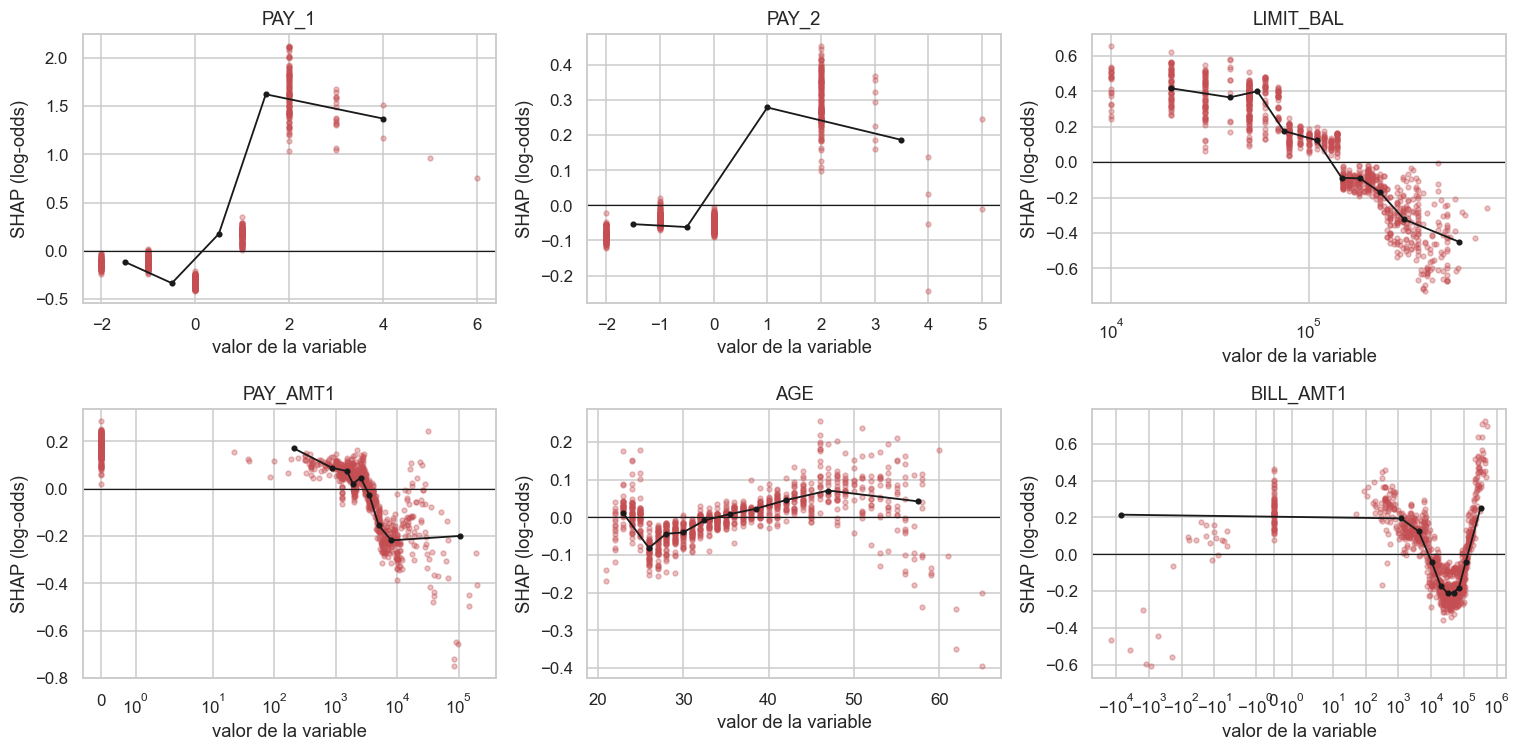

In [55]:
vars_dep = [v for v in ["PAY_1", "PAY_2", "LIMIT_BAL", "PAY_AMT1", "AGE", "BILL_AMT1"] if v in FEATURES]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for v, ax in zip(vars_dep, axes.ravel()):
    j = FEATURES.index(v)
    x_orig = X_te_raw.loc[X_cons.index, v] if v in X_te_raw.columns else X_cons[v]
    ax.scatter(x_orig, sv_cons[:, j], s=10, alpha=0.35, color=PALETA["xgb"])
    ax.axhline(0, c="k", lw=0.8)
    # tendencia por deciles
    q = pd.qcut(x_orig, 10, duplicates="drop")
    med = pd.Series(sv_cons[:, j], index=x_orig.index).groupby(q, observed=True).median()
    centros = [iv.mid for iv in med.index]
    ax.plot(centros, med.values, "o-", c="k", lw=1.2, ms=3)
    ax.set(title=v, xlabel="valor de la variable", ylabel="SHAP (log-odds)")
    if v in ("LIMIT_BAL", "PAY_AMT1", "BILL_AMT1"):
        ax.set_xscale("symlog")
plt.tight_layout()
guardar_fig("16_dependencia")

Los gráficos de dependencia permiten distinguir **efecto monótono** (coherente con el
criterio financiero) de **efecto no monótono** (donde la logística y SHAP-XGBoost tienen
que discrepar necesariamente, porque la primera no puede representarlo). Esto conecta
directamente con las discrepancias detectadas en el análisis 1.

In [56]:
# Efecto medio por código, para las seis variables de estado de pago
COD_MIN = 30   # códigos con menos casos que esto no se usan para juzgar monotonía


def efecto_por_codigo(var: str) -> pd.DataFrame:
    j = FEATURES.index(var)
    d = pd.DataFrame({"codigo": X_te_raw.loc[X_cons.index, var].values, "shap": sv_cons[:, j]})
    t = d.groupby("codigo")["shap"].agg(["mean", "median", "std", "count"])
    return t


tablas_mono = {v: efecto_por_codigo(v) for v in [f"PAY_{i}" for i in range(1, 7)]}
tabla_mono = tablas_mono["PAY_1"].round(4)
guardar_tabla(tabla_mono, "monotonia_PAY_1")

resumen_mono = pd.DataFrame({
    v: tablas_mono[v]["mean"].round(3) for v in tablas_mono
})
print(f"SHAP medio por código de estado de pago (celdas con n < {COD_MIN} entre paréntesis en el detalle):")
print(resumen_mono.to_string())
tabla_mono

SHAP medio por código de estado de pago (celdas con n < 30 entre paréntesis en el detalle):
        PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
codigo                                          
-2.0   -0.130 -0.083 -0.138 -0.070 -0.026 -0.036
-1.0   -0.110 -0.042 -0.078 -0.036 -0.011 -0.019
 0.0   -0.334 -0.060 -0.015 -0.017 -0.018 -0.036
 1.0    0.169    NaN    NaN    NaN    NaN    NaN
 2.0    1.633  0.294  0.319  0.223  0.287  0.267
 3.0    1.417  0.274  0.291  0.137  0.149  0.431
 4.0    1.344 -0.032  0.270  0.271  0.017    NaN
 5.0    0.957  0.117  0.225 -0.162    NaN  0.506
 6.0    0.755    NaN    NaN    NaN    NaN  0.376
 7.0      NaN    NaN  0.255 -0.162  0.066  0.401


,mean,median,std,count
codigo,,,,
-2.0,-0.1302,-0.1324,0.0455,89
-1.0,-0.1099,-0.1089,0.0515,176
0.0,-0.3342,-0.3355,0.0354,495
1.0,0.1686,0.1756,0.0681,119
2.0,1.6330,1.6221,0.2467,102
3.0,1.4167,1.3748,0.1937,15
4.0,1.3436,1.3436,0.2433,2
5.0,0.9566,0.9566,NaN,1
6.0,0.7548,0.7548,NaN,1


In [57]:
def monotonia(t: pd.DataFrame, n_min: int = COD_MIN) -> dict:
    """Monotonía real: relación entre el código y el efecto medio, solo con códigos frecuentes.

    Una Spearman sobre las observaciones individuales no puede detectar no monotonía, porque
    resume la relación en un único signo; aquí se mira el perfil de medias por código.
    """
    f = t[t["count"] >= n_min]
    if len(f) < 3:
        return {"codigos": len(f), "rho": np.nan, "reversiones": []}
    rho = stats.spearmanr(f.index.values, f["mean"].values).statistic
    dif = np.diff(f["mean"].values)
    rev = [(int(f.index[k]), int(f.index[k + 1]), round(float(dif[k]), 3))
           for k in range(len(dif)) if dif[k] < 0]
    return {"codigos": len(f), "rho": round(float(rho), 3), "reversiones": rev}


res_mono = pd.DataFrame({v: monotonia(t) for v, t in tablas_mono.items()}).T
print(f"Monotonía del efecto frente al código, usando solo códigos con n >= {COD_MIN}:")
print(res_mono.to_string())
guardar_tabla(res_mono.astype(str), "monotonia_estado_pago")

Monotonía del efecto frente al código, usando solo códigos con n >= 30:
      codigos  rho        reversiones
PAY_1       5  0.7  [(-1, 0, -0.224)]
PAY_2       4  0.8  [(-1, 0, -0.018)]
PAY_3       4  1.0                 []
PAY_4       4  1.0                 []
PAY_5       4  0.8  [(-1, 0, -0.008)]
PAY_6       4  0.4  [(-1, 0, -0.017)]


,codigos,rho,reversiones
PAY_1,5,0.7,"[(-1, 0, -0.224)]"
PAY_2,4,0.8,"[(-1, 0, -0.018)]"
PAY_3,4,1.0,[]
PAY_4,4,1.0,[]
PAY_5,4,0.8,"[(-1, 0, -0.008)]"
PAY_6,4,0.4,"[(-1, 0, -0.017)]"


El efecto de las variables de estado de pago **no es monótono**, y la reversión está bien
sostenida: el código 0 (uso de crédito *revolving*) es el estado más protector, por debajo de
`-1` (al corriente) y de `-2` (sin consumo), pese a que la codificación ordinal que se usa aquí
—y que emplea la literatura, incluidos Lin y Wang— lo coloca entre `-1` y `1`.

Esto es un **resultado, no un problema del montaje**. Significa que el orden numérico de los
códigos no refleja el orden de riesgo, y da contenido a la comprobación de robustez anotada en
el apartado 11.2: codificar `PAY_*` como categóricas en vez de como ordinales. Conecta además con
Lin y Wang, que sí hacen *one-hot* y encuentran que las dummies de códigos de pago concretos son
precisamente las inestables.

Conviene distinguir esta reversión de la caída que se observa a partir del código 2, que sí es
ruido: allí quedan muy pocos clientes por código.

<a id="s11"></a>
## 11. Resumen de resultados y exportación

In [58]:
resumen = {
    "dataset": "Default of Credit Card Clients (Taiwan, UCI #350)",
    "n_muestras": int(len(df)),
    "n_variables_matriz": len(FEATURES),
    "tasa_impago": round(float(y_all.mean()), 4),
    "semilla": SEED,
    "n_repeticiones": N_REPEATS,
    "n_clientes_explicados": int(len(X_expl)),
    "background_size": BACKGROUND_SIZE,
    "rendimiento": tabla_rend.to_dict(),
    "analisis_1_concordancia": {
        "spearman_rankings": round(float(rho), 4),
        "kendall_tau": round(float(tau), 4),
        f"coincidencias_top{TOP_K}": sol["coincidencias"],
        "cos_local_mediano": round(float(np.median(cos_local)), 4),
        "coincide_motivo_principal": round(float(coincide_top1), 4),
    },
    "analisis_2_estabilidad_entrenamiento": {
        "kendall_W_xgb": round(W_xgb, 4),
        "kendall_W_lr": round(W_lr, 4),
        "cos_local_medio_xgb": round(float(loc_xgb["cos_medio"].mean()), 4),
        "cos_local_medio_lr": round(float(loc_lr["cos_medio"].mean()), 4),
        "jaccard_top3_xgb": round(float(loc_xgb["jaccard_top3"].mean()), 4),
        "spearman_rank_vs_CV": round(float(r_cv.statistic), 4),
        "sra_prof10_xgb": round(float(sra(rep["xgb"]["global"], 10)), 4),
        "sra_prof10_lr": round(float(sra(rep["lr"]["global"], 10)), 4),
        "W_por_profundidad": {int(k): float(v) for k, v in robustez["W de Kendall"].items()},
    },
    "analisis_3_background": {
        "spearman_global_minimo": round(float(tabla_bg["Spearman_global"].min()), 4),
        "cos_local_medio_minimo": round(float(tabla_bg["cos_local_medio"].min()), 4),
        "max_cambio_motivo_principal_%": round(float(tabla_bg["cambia_motivo_principal_%"].max()), 2),
        "similitud_perfiles_normalizados_minima": round(
            float(tabla_base["similitud de perfiles normalizados"].min()), 4),
        "max_%_del_movimiento_que_es_desplazamiento": round(
            float(tabla_base["% del movimiento que es desplazamiento"].max()), 2),
        "brecha_mediana_cambian_de_motivo": round(
            float(brechas["brecha 1a-2a mediana (cambian)"].median()), 4),
        "brecha_mediana_mantienen_motivo": round(
            float(brechas["brecha 1a-2a mediana (no cambian)"].median()), 4),
    },
    "analisis_4_consistencia_coherencia": {
        "spearman_dist_features_vs_dist_shap": round(float(rho_c.statistic), 4),
        "cos_mediano_pares_proximos": round(float(cercanos["cos_shap"].median()), 4),
        "spearman_solo_variables_numericas": round(float(rho_num), 4),
        "variables_incoherentes": list(con_expectativa.index[con_expectativa["coherente"] == "NO"]),
    },
}

with open(OUT_DIR / "resumen_experimento.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print(json.dumps(resumen, indent=2, ensure_ascii=False))

{
  "dataset": "Default of Credit Card Clients (Taiwan, UCI #350)",
  "n_muestras": 30000,
  "n_variables_matriz": 26,
  "tasa_impago": 0.2212,
  "semilla": 42,
  "n_repeticiones": 100,
  "n_clientes_explicados": 200,
  "background_size": 200,
  "rendimiento": {
    "ROC-AUC": {
      "Regresión logística": 0.7175,
      "XGBoost": 0.7789
    },
    "PR-AUC": {
      "Regresión logística": 0.5033,
      "XGBoost": 0.5563
    },
    "KS": {
      "Regresión logística": 0.3695,
      "XGBoost": 0.431
    },
    "Brier": {
      "Regresión logística": 0.1455,
      "XGBoost": 0.1349
    },
    "LogLoss": {
      "Regresión logística": 0.4668,
      "XGBoost": 0.43
    }
  },
  "analisis_1_concordancia": {
    "spearman_rankings": 0.4797,
    "kendall_tau": 0.3538,
    "coincidencias_top5": 3,
    "cos_local_mediano": 0.4889,
    "coincide_motivo_principal": 0.305
  },
  "analisis_2_estabilidad_entrenamiento": {
    "kendall_W_xgb": 0.8584,
    "kendall_W_lr": 0.7009,
    "cos_local_medio_

In [59]:
# Se guardan las explicaciones de todas las repeticiones: recalcularlas cuesta varios
# minutos y así se puede rehacer cualquier medida del análisis 2 sin reentrenar.
np.savez_compressed(
    OUT_DIR / "explicaciones_repeticiones.npz",
    shap_xgb=rep["xgb"]["local"], shap_lr=rep["lr"]["local"],
    auc_xgb=np.array(rep["xgb"]["auc"]), auc_lr=np.array(rep["lr"]["auc"]),
    features=np.array(FEATURES), clientes=np.array(X_expl.index),
)
print("Guardado:", OUT_DIR / "explicaciones_repeticiones.npz")

Guardado: resultados\explicaciones_repeticiones.npz


In [60]:
print("Ficheros generados:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p}")

Ficheros generados:
  resultados\explicaciones_repeticiones.npz
  resultados\figuras\01_target.png
  resultados\figuras\02_distribuciones.png
  resultados\figuras\03_correlacion.png
  resultados\figuras\04_rendimiento.png
  resultados\figuras\05_importancia_global.png
  resultados\figuras\06_beeswarm.png
  resultados\figuras\07_waterfall_cliente.png
  resultados\figuras\08_concordancia_rankings.png
  resultados\figuras\09_concordancia_local.png
  resultados\figuras\09b_no_linealidad_aditivo.png
  resultados\figuras\10_estabilidad_global.png
  resultados\figuras\10b_convergencia_W.png
  resultados\figuras\10c_sra.png
  resultados\figuras\11_estabilidad_local.png
  resultados\figuras\12_estabilidad_vs_prediccion.png
  resultados\figuras\13_background.png
  resultados\figuras\13b_background_desplazamiento.png
  resultados\figuras\13c_brecha_motivo.png
  resultados\figuras\14_background_cliente.png
  resultados\figuras\15_consistencia.png
  resultados\figuras\16_dependencia.png
  resultado

### 11.1 Cómo pasar esto a la memoria

Cada análisis produce una tabla y una figura pensadas para ir directamente al documento:

| Sección de la memoria | Tabla | Figura |
|---|---|---|
| Datos y preparación | `rendimiento_modelos` | `01`–`04` |
| Explicaciones (caso base) | `importancia_global`, `coeficientes_logistica` | `05`–`07` |
| Análisis 1 | `concordancia_rankings`, `signos_efecto` | `08`, `09` |
| Análisis 2 | `estabilidad_global_xgb/lr`, `comparativa_estabilidad_global`, `sra_profundidad`, `robustez_profundidad` | `10`–`12` |
| Análisis 3 | `estabilidad_background`, `background_desplazamiento_base`, `background_brecha_motivo` | `13`, `13b`, `13c`, `14` |
| Análisis 4 | `consistencia_pares`, `coherencia_signos` | `15`, `16` |

### 11.2 Antes de la versión definitiva

- **Segundo dataset**: repetir los apartados 8 y 9 con South German Credit (n = 1.000) para
  contrastar el efecto del tamaño muestral. Solo hay que sustituir la carga y el
  diccionario; el resto de funciones son independientes del dataset.
- **Comprobaciones de robustez pendientes**: codificar `PAY_*` como categóricas en lugar de
  ordinales y probar `scale_pos_weight` en XGBoost (Chen et al., 2024, y Ballegeer et al.,
  2025, relacionan desequilibrio y coste con la estabilidad). La robustez a la profundidad
  (`max_depth ∈ {3, 4, 6}`) ya está resuelta en el apartado 8.1, y el análisis 1 ya no
  depende de los coeficientes crudos: usa SHAP sobre la logística y, por separado, el
  modelo aditivo del apartado 7.3.
- **Duplicados**: hay perfiles repetidos que caen a ambos lados de la partición. Aquí se
  mantienen y se documentan, y sirven de comprobación en el análisis 4; para la memoria hay
  que decidir con las tutoras si se agrupan antes de partir.
- **Decisiones pendientes con las tutoras**: forma de comparar con la logística
  (coeficientes o SHAP), número de repeticiones y alcance del análisis 3 (composición
  frente a composición + tamaño).